# AM115 Final Project CoLab Notebook

Trey Whitehead and Liam Bieber

Data Scraping Notebook to generate data: https://colab.research.google.com/drive/1y8Ssp_ihePpfhEb8uSWJYGIAlI7ndV-h#scrollTo=WH8sHCT8VA5Y

Uploaded Data on Kaggle: https://www.kaggle.com/datasets/charleswhitehead/western-hockey-league-statistics



# Section 0: Importing Libraries and Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import itertools

In [ ]:
path = kagglehub.dataset_download("charleswhitehead/whl-stats-and-trades")
print("Path to dataset files:", path)

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("CSV files in dataset:", csv_files)

# Load each CSV file into a dictionary of DataFrames
dataframes = {}
for csv_file in csv_files:
    file_path = os.path.join(path, csv_file)
    dataframes[csv_file] = pd.read_csv(file_path)

100%|██████████| 5.41M/5.41M [00:00<00:00, 36.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/charleswhitehead/whl-stats-and-trades/versions/7
CSV files in dataset: ['all_team_trades_sorted.csv', 'full_game_by_game_stats_2025.csv', 'full_WHL_roster_data.csv', 'whl_processed_roster_data_v2.csv', 'full_game_by_game_stats.csv', 'whl_team_data_all_seasons_v5.csv']


In [ ]:
# Quick scan of dataset (un-hide output to view)
for csv in csv_files:
    print(csv)
    display(dataframes[csv].head(5))
    display(dataframes[csv].info())

all_team_trades_sorted.csv


,Original Index,Year,Date,Team,Traded To,Asset 1 traded from Team 1,Asset 2 traded from Team 1,Asset 3 traded from Team 1,Asset 4 traded from Team 1,Asset 5 traded from Team 1,...,Asset 5 traded from Team 2,Asset 6 traded from Team 2,Asset 7 traded from Team 2,Asset 8 traded from Team 2,Asset 9 traded from Team 2,Asset 10 traded from Team 2,Asset 11 traded from Team 2,Asset 12 traded from Team 2,Asset 13 traded from Team 2,Asset 14 traded from Team 2
0,855,2019,2018-05-03,Portland,Saskatoon,Kurtis Smythe,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,844,2019,2018-05-03,Red Deer,Seattle,3rd Rnd. ’18,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,850,2019,2018-05-03,Red Deer,Kelowna,9th Rnd. ’18,10th Rnd. ’18,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,852,2019,2018-05-03,Tri-City,Edmonton,10th Rnd. ’18,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,855,2019,2018-05-03,Saskatoon,Portland,Kurtis Smythe,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1278 entries, 0 to 1277
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Original Index               1278 non-null   int64 
 1   Year                         1278 non-null   int64 
 2   Date                         1278 non-null   object
 3   Team                         1278 non-null   object
 4   Traded To                    1272 non-null   object
 5   Asset 1 traded from Team 1   1278 non-null   object
 6   Asset 2 traded from Team 1   244 non-null    object
 7   Asset 3 traded from Team 1   85 non-null     object
 8   Asset 4 traded from Team 1   34 non-null     object
 9   Asset 5 traded from Team 1   7 non-null      object
 10  Asset 6 traded from Team 1   6 non-null      object
 11  Asset 1 traded from Team 2   1272 non-null   object
 12  Asset 2 traded from Team 2   422 non-null    object
 13  Asset 3 traded from Team 2   176 

None

full_game_by_game_stats_2025.csv


...

None

whl_team_data_all_seasons_v5.csv


,season,season_id,full_team_name,team_name,team_id,conference rank,gp,w,l,otl,...,pts,pct,gf,ga,stk,p10,s/o,pim,goals_per_game,goalsagainst_per_game
0,2024,281,Saskatoon Blades,Saskatoon,213,1,68,50,13,2,...,105,0.772,255,163,3-0-0-0,8-2-0-0,2-3,614,3.750000,2.397059
1,2024,281,Swift Current Broncos,Swift Current,216,2,68,40,22,4,...,86,0.632,286,239,0-1-0-0,7-3-0-0,1-2,836,4.205882,3.514706
2,2024,281,Moose Jaw Warriors,Moose Jaw,207,3,68,44,21,0,...,91,0.669,297,228,1-0-0-0,7-2-0-1,2-3,629,4.367647,3.352941
3,2024,281,Medicine Hat Tigers,Medicine Hat,206,4,68,37,23,6,...,82,0.603,280,231,2-0-1-0,4-5-1-0,1-2,866,4.117647,3.397059
4,2024,281,Red Deer Rebels,Red Deer,211,5,68,33,26,3,...,75,0.551,213,217,0-4-1-0,3-6-1-0,3-6,811,3.132353,3.191176


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   season                 220 non-null    int64  
 1   season_id              220 non-null    int64  
 2   full_team_name         220 non-null    object 
 3   team_name              220 non-null    object 
 4   team_id                220 non-null    int64  
 5   conference rank        220 non-null    int64  
 6   gp                     220 non-null    int64  
 7   w                      220 non-null    int64  
 8   l                      220 non-null    int64  
 9   otl                    220 non-null    int64  
 10  sl                     220 non-null    int64  
 11  pts                    220 non-null    int64  
 12  pct                    220 non-null    float64
 13  gf                     220 non-null    int64  
 14  ga                     220 non-null    int64  
 15  stk   

None

In [ ]:
stats_db = dataframes['full_game_by_game_stats.csv']
stats2025_db = dataframes['full_game_by_game_stats_2025.csv']
trades_db = dataframes['all_team_trades_sorted.csv']
roster_db = dataframes['whl_processed_roster_data_v2.csv']
team_db = dataframes['whl_team_data_all_seasons_v5.csv']

In [ ]:
# Filter the dataframe for the 2024 season and get unique team_ids
unique_team_ids_2024 = team_db[team_db['season'] == 2024]['team_id'].unique()
print(unique_team_ids_2024)

[213 216 207 206 211 201 205 209 202 228 212 210 208 226 222 204 223 227
 215 214 217 203]


# Section 1: Cleaning Data and Synthesizing Data Frames

In [ ]:
team_id_mapping = {
    'Brandon': '201', 'Calgary': '202', 'Kamloops': '203', 'Kelowna': '204',
    'Lethbridge': '205', 'Medicine Hat': '206', 'Moose Jaw': '207', 'Portland': '208',
    'Prince Albert': '209', 'Prince George': '210', 'Red Deer': '211', 'Regina': '212',
    'Saskatoon': '213', 'Seattle': '214', 'Spokane': '215', 'Swift Current': '216',
    'Tri-City': '217', 'Wenatchee': '222', 'Winnipeg': '222', 'Kootenay': '222',
    'Vancouver': '223', 'Everett': '226', 'Victoria': '227', 'Edmonton': '228'
}

season_mapping = {
    281: "2024", 279: "2023", 275: "2022", 266: "2019", 262: "2018",
    257: "2017", 251: "2016", 249: "2015", 245: "2014", 242: "2013"
}

In [ ]:
trades_db['team_id'] = trades_db['Team'].map(team_id_mapping)

# Map traded team names ('Traded To') to team_id
trades_db['traded_team_id'] = trades_db['Traded To'].map(team_id_mapping)

trades_db['season'] = trades_db['Year'].astype(int)

trades_db.rename(columns={
    'Date': 'date',
    'Asset 1 traded from Team 1': 'asset_1_team_1',
    'Asset 2 traded from Team 1': 'asset_2_team_1',
    'Asset 3 traded from Team 1': 'asset_3_team_1',
    'Asset 4 traded from Team 1': 'asset_4_team_1',
    'Asset 5 traded from Team 1': 'asset_5_team_1',
    'Asset 6 traded from Team 1': 'asset_6_team_1',
    'Asset 1 traded from Team 2': 'asset_1_team_2',
    'Asset 2 traded from Team 2': 'asset_2_team_2',
    'Asset 3 traded from Team 2': 'asset_3_team_2',
    'Asset 4 traded from Team 2': 'asset_4_team_2',
    'Asset 5 traded from Team 2': 'asset_5_team_2',
    'Asset 6 traded from Team 2': 'asset_6_team_2',
    'Asset 7 traded from Team 2': 'asset_7_team_2',
    'Asset 8 traded from Team 2': 'asset_8_team_2',
    'Asset 9 traded from Team 2': 'asset_9_team_2',
    'Asset 10 traded from Team 2': 'asset_10_team_2',
    'Asset 11 traded from Team 2': 'asset_11_team_2',
    'Asset 12 traded from Team 2': 'asset_12_team_2',
    'Asset 13 traded from Team 2': 'asset_13_team_2',
    'Asset 14 traded from Team 2': 'asset_14_team_2'
}, inplace=True)

In [ ]:
trades_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1278 entries, 0 to 1277
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Original Index   1278 non-null   int64 
 1   Year             1278 non-null   int64 
 2   date             1278 non-null   object
 3   Team             1278 non-null   object
 4   Traded To        1272 non-null   object
 5   asset_1_team_1   1278 non-null   object
 6   asset_2_team_1   244 non-null    object
 7   asset_3_team_1   85 non-null     object
 8   asset_4_team_1   34 non-null     object
 9   asset_5_team_1   7 non-null      object
 10  asset_6_team_1   6 non-null      object
 11  asset_1_team_2   1272 non-null   object
 12  asset_2_team_2   422 non-null    object
 13  asset_3_team_2   176 non-null    object
 14  asset_4_team_2   76 non-null     object
 15  asset_5_team_2   44 non-null     object
 16  asset_6_team_2   28 non-null     object
 17  asset_7_team_2   22 non-null     

In [ ]:
# Filter rows where 'team_id' or 'traded_team_id' are NaN
trades_with_missing_team = trades_db[trades_db['team_id'].isna() | trades_db['traded_team_id'].isna()]

# Display the rows with missing values in either 'team_id' or 'traded_team_id'
print(trades_with_missing_team)

      Original Index  Year        date           Team   Traded To  \
691              511  2022  2021-12-27  Prince George         NaN   
693              512  2022  2021-12-27   Medicine Hat         NaN   
695              510  2022  2021-12-27      Saskatoon         NaN   
1055             112  2024  2023-11-23     Tri-Cities     Calgary   
1056             112  2024  2023-11-23        Calgary  Tri-Cities   
1109              83  2024  2024-01-10       Edmonton         NaN   
1110              82  2024  2024-01-10        Kelowna         NaN   
1126              81  2024  2024-01-10      Saskatoon         NaN   

               asset_1_team_1              asset_2_team_1  \
691    Kyren Gronick (to SAS)        5th Rnd. ’25 (to MH)   
693   Carlin Dezainde (to PG)       Cayden Glover (to PG)   
695    Pavel Bocharov (to MH)         Brendan Lee (to MH)   
1055          Carter MacAdams                         NaN   
1056          Carter MacAdams                         NaN   
1109  Carter

In [ ]:
stats_db.head(50)

stats_db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 562364 entries, 0 to 562363
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   season_id            562364 non-null  int64  
 1   season               562364 non-null  int64  
 2   date                 562364 non-null  object 
 3   opponent_id          562364 non-null  int64  
 4   opponent             562364 non-null  object 
 5   team_id              562364 non-null  int64  
 6   home_status          562364 non-null  int64  
 7   game_result          562364 non-null  object 
 8   game_result_encoded  562364 non-null  int64  
 9   player_number        562364 non-null  float64
 10  last_name            562364 non-null  object 
 11  game_status          562364 non-null  int64  
 12  position             562364 non-null  float64
 13  goals                562364 non-null  float64
 14  assists              562364 non-null  float64
 15  shots            

In [ ]:
import pickle

# Open the player stats pickle file and load into player_roster DataFrame
with open('whl_player_stats.pkl', 'rb') as player_file:
    player_roster = pickle.load(player_file)

# Open the goalie stats pickle file and load into goalie_roster DataFrame
with open('whl_goalie_stats.pkl', 'rb') as goalie_file:
    goalie_roster = pickle.load(goalie_file)

# Process player_roster
player_roster['Team_ID'] = player_roster['Team_ID'].str.replace('Team_', '', regex=False)
player_roster[['first_part', 'last_name']] = player_roster['Player'].str.split(' ', n=1, expand=True)
player_roster = player_roster.drop(columns=['first_part'])
player_selected_columns = ['last_name', 'Player', 'Number', 'Season_ID', 'Team_ID']
player_roster = player_roster[player_selected_columns]

# Process goalie_roster
goalie_roster['Team_ID'] = goalie_roster['Team_ID'].str.replace('Team_', '', regex=False)
goalie_roster[['first_part', 'last_name']] = goalie_roster['Goalie'].str.split(' ', n=1, expand=True)
goalie_roster = goalie_roster.drop(columns=['first_part'])

# Rename 'Goalie' to 'Player'
goalie_roster = goalie_roster.rename(columns={'Goalie': 'Player'})
goalie_selected_columns = ['last_name', 'Player', 'Number', 'Season_ID', 'Team_ID']
goalie_roster = goalie_roster[goalie_selected_columns]

combined_roster = pd.concat([player_roster, goalie_roster], ignore_index=True)
combined_roster = combined_roster.rename(columns={
    'last_name': 'last_name',
    'Player': 'player_name',
    'Number': 'player_number',
    'Season_ID': 'season_id',
    'Team_ID': 'team_id'
})

combined_roster['last_name'] = combined_roster['last_name'].str.replace(r'\s*\(total\)', '', regex=True)
combined_roster['player_name'] = combined_roster['player_name'].str.replace(r'\s*\(total\)', '', regex=True)

In [ ]:
# This function generates all possible combinations of player_number, season_id, and team_id
# for all unique combinations
# Parameters: combined_roster ... DataFrame containing player data
# Returns: a DF that contains all cobinations

def generate_combinations_for_all_players(combined_roster):
    all_combinations = []
    unique_players = combined_roster[['last_name', 'player_name']].drop_duplicates()

    for _, row in unique_players.iterrows():
        last_name = row['last_name']
        player_name = row['player_name']

        player_entries = combined_roster[combined_roster['last_name'] == last_name]

        # Get unique values for player_number, season_id, and team_id
        player_numbers = player_entries['player_number'].unique()
        season_ids = player_entries['season_id'].unique()
        team_ids = player_entries['team_id'].unique()

        # Generate all possible combinations of player_number, season_id, and team_id, then create DataFrame for combinations
        combinations = list(itertools.product(player_numbers, season_ids, team_ids))
        combinations_df = pd.DataFrame(combinations, columns=['player_number', 'season_id', 'team_id'])
        combinations_df['player_name'] = player_name
        combinations_df['last_name'] = last_name

        all_combinations.append(combinations_df)

    final_df = pd.concat(all_combinations, ignore_index=True)

    return final_df

all_player_combinations = generate_combinations_for_all_players(combined_roster)

print(all_player_combinations.head())

   player_number  season_id team_id   player_name last_name
0           74.0        281     201  Brett Hyland    Hyland
1           74.0        279     201  Brett Hyland    Hyland
2           74.0        275     201  Brett Hyland    Hyland
3            7.0        281     201  Brett Hyland    Hyland
4            7.0        279     201  Brett Hyland    Hyland


In [ ]:
all_player_combinations = all_player_combinations.rename(columns={
    'last_name': 'last_name',
    'Player': 'player_name',
    'Number': 'player_number',
    'Season_ID': 'season_id',
    'Team_ID': 'team_id'
})

all_player_combinations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236234 entries, 0 to 236233
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   player_number  236234 non-null  float64
 1   season_id      236234 non-null  int64  
 2   team_id        236234 non-null  object 
 3   player_name    236234 non-null  object 
 4   last_name      236234 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 9.0+ MB


In [ ]:
# Filter out entries prior to season 2017
stats_db = stats_db[stats_db['season'] >= 2017]

# Ensure the player last names are not capitalized (all lowercase)
stats_db['last_name'] = stats_db['last_name'].str.lower()
all_player_combinations['last_name'] = all_player_combinations['last_name'].str.lower()

stats_db['team_id'] = stats_db['team_id'].astype(str)
all_player_combinations['team_id'] = all_player_combinations['team_id'].astype(str)
stats_db['player_number'] = stats_db['player_number'].astype(str)
all_player_combinations['player_number'] = all_player_combinations['player_number'].astype(str)

# Perform a left join to add full_name from combined_roster to stats_db
full_df = pd.merge(
    stats_db,
    all_player_combinations[['season_id', 'team_id', 'player_number', 'last_name', 'player_name']],
    on=['season_id', 'team_id', 'player_number', 'last_name'],
    how='left'
)

full_df_filtered = full_df[full_df['game_status'] == 1]

<ipython-input-14-7b4c6b2655e4>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stats_db['last_name'] = stats_db['last_name'].str.lower()
<ipython-input-14-7b4c6b2655e4>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stats_db['team_id'] = stats_db['team_id'].astype(str)
<ipython-input-14-7b4c6b2655e4>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.

In [ ]:
# Remove rows where the combination of 'date', 'team_id', and 'last_name' are the same
full_df = full_df_filtered.drop_duplicates(subset=['date', 'team_id', 'last_name'])

In [ ]:
# Sort the DataFrame by last_name, team_id, and player_number
full_df_sorted = full_df.sort_values(by=['last_name', 'team_id', 'player_number'])

In [ ]:
# Forward fill NaN values in the 'player_name' column
full_df_sorted['player_name'] = full_df_sorted['player_name'].fillna(method='ffill')

<ipython-input-17-619eb0360782>:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  full_df_sorted['player_name'] = full_df_sorted['player_name'].fillna(method='ffill')


In [ ]:
# Create a condition to check if 'last_name' is not in 'player_name' (both in lowercase)
mask = full_df_sorted['last_name'].str.lower() != full_df_sorted['player_name'].str.lower().str.split().str[-1]

# Update 'player_name' to 'X last_name' where the condition is true
full_df_sorted.loc[mask, 'player_name'] = 'X ' + full_df_sorted.loc[mask, 'last_name']

In [ ]:
pd.set_option('display.max_rows', 10000)
pd.set_option('display.max_columns', None)

In [ ]:
full_df_sorted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 172993 entries, 514489 to 130355
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   season_id            172993 non-null  int64  
 1   season               172993 non-null  int64  
 2   date                 172993 non-null  object 
 3   opponent_id          172993 non-null  int64  
 4   opponent             172993 non-null  object 
 5   team_id              172993 non-null  object 
 6   home_status          172993 non-null  int64  
 7   game_result          172993 non-null  object 
 8   game_result_encoded  172993 non-null  int64  
 9   player_number        172993 non-null  object 
 10  last_name            172993 non-null  object 
 11  game_status          172993 non-null  int64  
 12  position             172993 non-null  float64
 13  goals                172993 non-null  float64
 14  assists              172993 non-null  float64
 15  shots            

In [ ]:
# Filter for Braxton Whitehead in the 2024 season
braxton_whitehead_goals_2024 = full_df_sorted[(full_df_sorted['player_name'] == 'Braxton Whitehead') & (full_df_sorted['season'] == 2024)]

# Sum up the goals for Braxton Whitehead in the 2024 season
total_goals = braxton_whitehead_goals_2024['assists'].sum() + braxton_whitehead_goals_2024['goals'].sum()

total_games = braxton_whitehead_goals_2024['game_status'].sum()

# Display the total goals
print(f"Total points for Braxton Whitehead in the 2024 season: {total_goals} in {total_games} games.")

# IT ACTUALLY WORKS!

Total points for Braxton Whitehead in the 2024 season: 52.0 in 52 games.


In [ ]:
full_df_sorted.to_csv('full_WHL_roster_data.csv')

# Section 2: Random Walk Models


In [ ]:
random_factor = 1

In [ ]:
team_roster_data = pd.read_csv('full_WHL_roster_data.csv')

# Sum the goals scored and goals against by each team in each game, grouped by season, team, and date
goals_sum = team_roster_data.groupby(['season_id', 'team_id', 'date'])['goals'].sum().reset_index()
goals_against_sum = team_roster_data.groupby(['season_id', 'team_id', 'date'])['goals_against'].sum().reset_index()

# Calculate the standard deviation of the summed goals scored and goals against across all games for each team in each season
std_goals = goals_sum.groupby(['season_id', 'team_id'])['goals'].std().reset_index()
std_goals_against = goals_against_sum.groupby(['season_id', 'team_id'])['goals_against'].std().reset_index()

std_goals.rename(columns={'goals': 'std_goals_per_season'}, inplace=True)
std_goals_against.rename(columns={'goals_against': 'std_goals_against_per_season'}, inplace=True)

team_db = team_db.merge(std_goals, on=['season_id', 'team_id'], how='left')
team_db = team_db.merge(std_goals_against, on=['season_id', 'team_id'], how='left')

In [ ]:
team_db.head(10)

,season,season_id,full_team_name,team_name,team_id,conference rank,gp,w,l,otl,sl,pts,pct,gf,ga,stk,p10,s/o,pim,goals_per_game,goalsagainst_per_game,std_goals_per_season,std_goals_against_per_season
0,2024,281,Saskatoon Blades,Saskatoon,213,1,68,50,13,2,3,105,0.772,255,163,3-0-0-0,8-2-0-0,2-3,614,3.750000,2.397059,1.859591,1.588755
1,2024,281,Swift Current Broncos,Swift Current,216,2,68,40,22,4,2,86,0.632,286,239,0-1-0-0,7-3-0-0,1-2,836,4.205882,3.514706,2.031955,1.705489
2,2024,281,Moose Jaw Warriors,Moose Jaw,207,3,68,44,21,0,3,91,0.669,297,228,1-0-0-0,7-2-0-1,2-3,629,4.367647,3.352941,2.230121,1.755651
3,2024,281,Medicine Hat Tigers,Medicine Hat,206,4,68,37,23,6,2,82,0.603,280,231,2-0-1-0,4-5-1-0,1-2,866,4.117647,3.397059,2.431999,1.845670
4,2024,281,Red Deer Rebels,Red Deer,211,5,68,33,26,3,6,75,0.551,213,217,0-4-1-0,3-6-1-0,3-6,811,3.132353,3.191176,1.421953,1.702848
5,2024,281,Brandon Wheat Kings,Brandon,201,6,68,33,28,6,1,73,0.537,225,244,3-0-0-0,4-5-1-0,2-1,946,3.308824,3.588235,2.013726,2.032441
6,2024,281,Lethbridge Hurricanes,Lethbridge,205,7,68,33,28,7,0,73,0.537,214,210,3-0-2-0,6-2-2-0,3-0,660,3.147059,3.088235,2.117022,1.744425
7,2024,281,Prince Albert Raiders,Prince Albert,209,8,68,31,32,2,3,67,0.493,215,221,0-2-0-0,3-6-1-0,6-3,825,3.161765,3.250000,1.721819,1.523304
8,2024,281,Calgary Hitmen,Calgary,202,9,68,28,31,8,1,65,0.478,250,255,1-0-0-0,4-5-1-0,0-1,942,3.676471,3.750000,2.281929,1.725703
9,2024,281,Edmonton Oil Kings,Edmonton,228,10,68,27,37,3,1,58,0.426,227,301,2-0-0-0,6-3-1-0,0-1,903,3.338235,4.426471,1.905297,2.224998


In [ ]:
def poisson_sim(n_simulations, gp, avg_goals, avg_goals_against, std_dev_goals, std_dev_goals_against, random_factor, all_goals_simulations, all_goals_against_simulations, all_goal_differential_simulations):
    for i in range(n_simulations):
        # Simulate goals scored and goals against using Poisson distribution
        random_goals_against = -np.random.poisson(lam=avg_goals_against, size=gp)  # Invert: use avg_goals for goals against
        random_goals = np.random.poisson(lam=avg_goals, size=gp)  # Invert: use avg_goals_against for goals scored

        # Calculate cumulative goals, goals against, and goal differential
        all_goals_simulations[i] = np.cumsum(random_goals)
        all_goals_against_simulations[i] = np.cumsum(random_goals_against)
        all_goal_differential_simulations[i] = all_goals_simulations[i] + all_goals_against_simulations[i]

    plt.figure(figsize=(12, 6))
    plt.title(f"Poisson Random Walk Trajectories (2024 Regina Pats)", fontsize = 18, fontweight='bold')

def gaussian_sim(n_simulations, gp, avg_goals, avg_goals_against, std_dev_goals, std_dev_goals_against, random_factor, all_goals_simulations, all_goals_against_simulations, all_goal_differential_simulations):
    for i in range(n_simulations):
        # Simulate goals scored and goals against for each game
        random_goals_against = - np.random.normal(loc=avg_goals_against, scale=random_factor * std_dev_goals_against, size=gp)
        random_goals = np.random.normal(loc=avg_goals, scale=random_factor * std_dev_goals, size=gp)

        # Clip negative values (since goals can't be negative)
        random_goals = np.clip(random_goals, 0, None)
        random_goals_against = np.clip(random_goals_against, None, 0)

        # Calculate cumulative goals, goals against, and goal differential
        all_goals_simulations[i] = np.cumsum(random_goals)
        all_goals_against_simulations[i] = np.cumsum(random_goals_against)
        all_goal_differential_simulations[i] = all_goals_simulations[i] + all_goals_against_simulations[i]

    plt.figure(figsize=(12, 6))
    plt.title(f"Gaussian Random Walk Trajectories (2024 Regina Pats)", fontsize = 18, fontweight='bold')

In [ ]:
# Function to sim goals scored, against, differential - counts wins
# Parameters: team DB, team ID, season ID, and num of sims

def simulate_goals(team_db, func, team_id, season_id, n_simulations=1000):

    team_season_data = team_db[(team_db['team_id'] == team_id) & (team_db['season_id'] == season_id)]

    if team_season_data.empty:
        print(f"No data found for team_id={team_id} and season_id={season_id}.")
        return

    # Number of games played
    gp = int(team_season_data['gp'].iloc[0])

    # Mean and standard deviation of goals scored and goals against
    avg_goals = team_season_data['goals_per_game'].iloc[0]
    std_dev_goals = team_season_data['std_goals_per_season'].iloc[0]

    avg_goals_against = team_season_data['goalsagainst_per_game'].iloc[0]
    std_dev_goals_against = team_season_data['std_goals_against_per_season'].iloc[0]

    random_factor = 3

    # Storage for simulations
    all_goals_simulations = np.zeros((n_simulations, gp))
    all_goals_against_simulations = np.zeros((n_simulations, gp))
    all_goal_differential_simulations = np.zeros((n_simulations, gp))
    win_counts = np.zeros(n_simulations)

    # Call the simulation function
    func(n_simulations, gp, avg_goals, avg_goals_against, std_dev_goals, std_dev_goals_against, random_factor, all_goals_simulations, all_goals_against_simulations, all_goal_differential_simulations)

    # Count wins based on goal differential (where positive)
    for i in range(n_simulations):
        win_counts[i] = np.sum(all_goal_differential_simulations[i] > 0)

    # Calculate mean and confidence intervals
    mean_goals = np.mean(all_goals_simulations, axis=0)
    mean_goals_against = np.mean(all_goals_against_simulations, axis=0)
    mean_goal_differential = np.mean(all_goal_differential_simulations, axis=0)

    lower_goals = np.percentile(all_goals_simulations, 2.5, axis=0)
    upper_goals = np.percentile(all_goals_simulations, 97.5, axis=0)

    lower_goals_against = np.percentile(all_goals_against_simulations, 2.5, axis=0)
    upper_goals_against = np.percentile(all_goals_against_simulations, 97.5, axis=0)

    lower_goal_differential = np.percentile(all_goal_differential_simulations, 2.5, axis=0)
    upper_goal_differential = np.percentile(all_goal_differential_simulations, 97.5, axis=0)

    # Plot 10 trajectories for goal differential
    for i in range(10):
        plt.plot(range(1, gp + 1), all_goal_differential_simulations[i], color='blue', alpha=0.5)

    # Plot 10 trajectories for goals scored
    for i in range(10):
        plt.plot(range(1, gp + 1), all_goals_simulations[i], color='green', alpha=0.5)

    # Plot 10 trajectories for goals against (negating goals against)
    for i in range(10):
        plt.plot(range(1, gp + 1), all_goals_against_simulations[i], color='red', alpha=0.5)

    # Plot average trajectories with bold lines
    plt.plot(range(1, gp + 1), mean_goal_differential, color='blue', linewidth=2, label=f'Average Goal Differential: {mean_goal_differential[-1]}')
    plt.plot(range(1, gp + 1), mean_goals, color='green', linewidth=2, label=f'Average Goals Scored: {mean_goals[-1]}')
    plt.plot(range(1, gp + 1), mean_goals_against, color='red', linewidth=2, label=f'Average Goals Against: {mean_goals_against[-1]}')

    gf1 = team_season_data['gf'].iloc[0]
    ga1 = team_season_data['ga'].iloc[0]
    diff1 = gf1 - ga1

    plt.scatter(70, mean_goal_differential[-1], label=f'Actual Differential: {diff1}', color='blue', s=200, marker='x')
    plt.scatter(70, mean_goals[-1], label=f'Actual Goals For: {gf1}', color='green', s=200, marker='x')
    plt.scatter(70, mean_goals_against[-1], label=f'Actual Goals Against: {ga1}', color='red', s=200, marker='x')

    plt.fill_between(range(1, gp + 1), lower_goal_differential, upper_goal_differential, color='blue', alpha=0.2, label='95% Confidence Interval for Goal Differential')
    plt.fill_between(range(1, gp + 1), lower_goals, upper_goals, color='green', alpha=0.2, label='95% Confidence Interval for Goals Scored')
    plt.fill_between(range(1, gp + 1), upper_goals_against, lower_goals_against, color='red', alpha=0.2, label='95% Confidence Interval for Goals Against')

    plt.xlabel("Game Number", fontsize = 14, fontweight='bold')
    plt.ylabel("Goals", fontsize = 14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

    # Plot the projected wins distribution
    plt.figure(figsize=(8, 6))
    plt.hist(win_counts, bins=20, color='green', edgecolor='black', alpha=0.7)
    plt.axvline(np.mean(win_counts), color='red', linestyle='dashed', linewidth=2, label=f'Mean Wins: {np.mean(win_counts):.2f}')
    plt.axvline(np.percentile(win_counts, 95), color='black', linestyle='dashed', linewidth=2, label=f'95th Percentile: {np.percentile(win_counts, 95):.2f}')
    plt.axvline(np.percentile(win_counts, 5), color='black', linestyle='dashed', linewidth=2, label=f'5th Percentile: {np.percentile(win_counts, 5):.2f}')
    plt.title("Projected Wins Distribution (2024 Regina Pats)", fontsize = 18, fontweight='bold')
    plt.xlabel("Number of Wins", fontsize = 14, fontweight='bold')
    plt.ylabel("Frequency", fontsize = 14, fontweight='bold')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

    # Create a table with win counts and other statistics
    win_summary = {
        'season_id': season_id,
        'team_id': team_id,
        'average_wins': np.mean(win_counts),
        'wins_95_percentile': np.percentile(win_counts, 95),
        'wins_5_percentile': np.percentile(win_counts, 5)
    }

    return win_summary

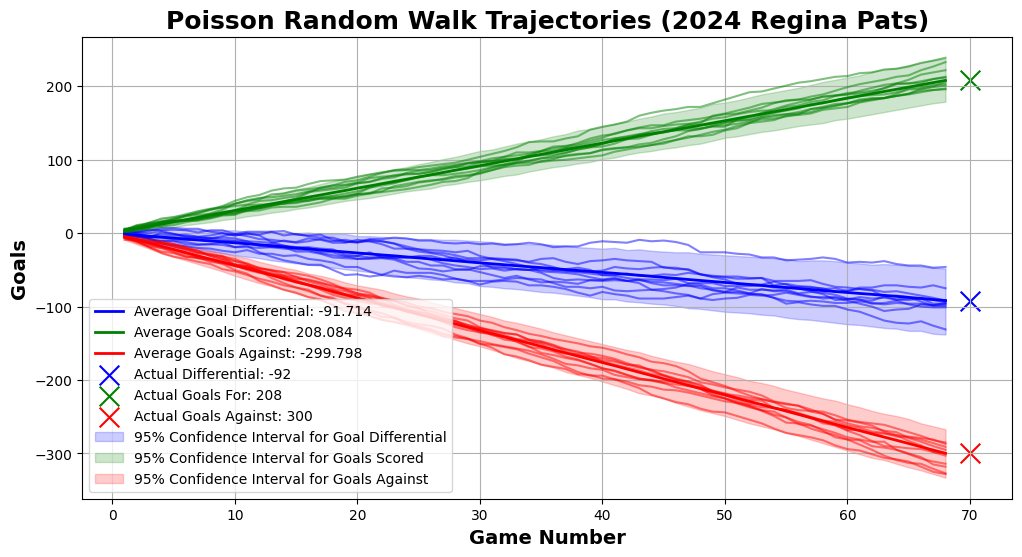

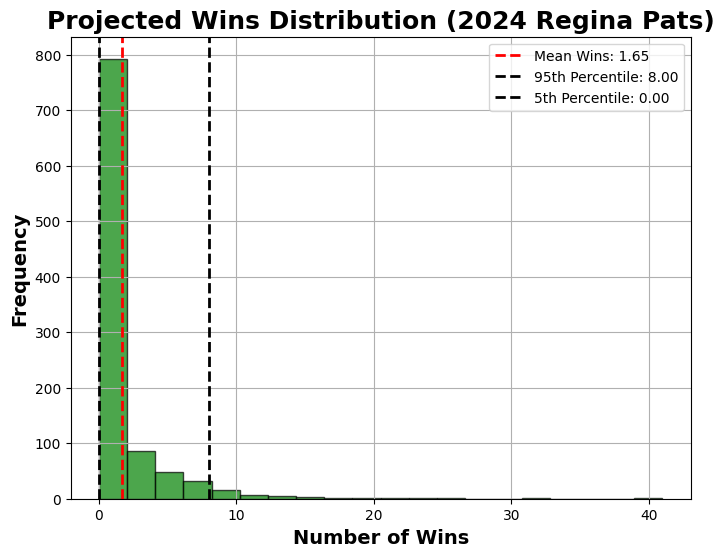

{'season_id': 281,
 'team_id': 212,
 'average_wins': 1.653,
 'wins_95_percentile': 8.0,
 'wins_5_percentile': 0.0}

In [ ]:
simulate_goals(team_db, poisson_sim, team_id=212, season_id=281, n_simulations=1000)

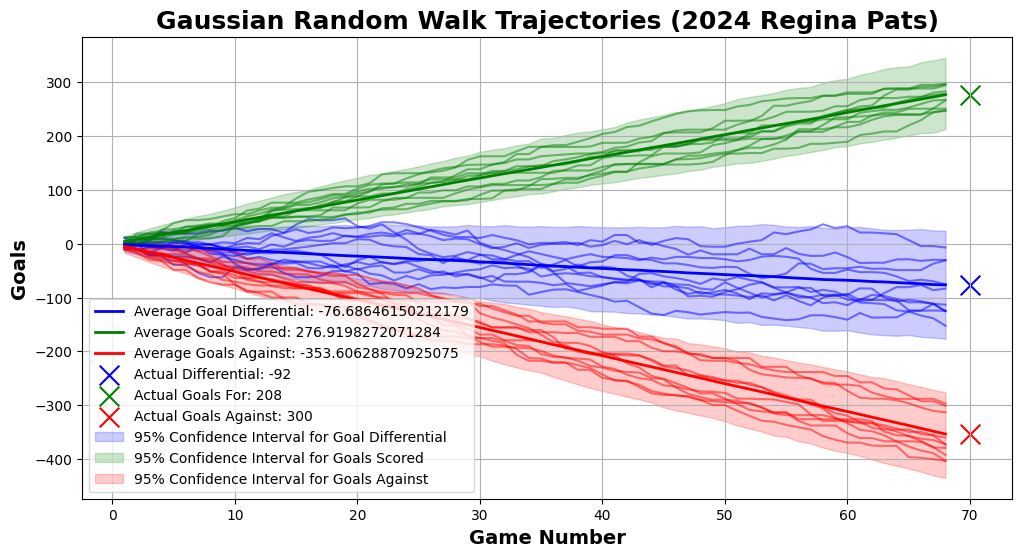

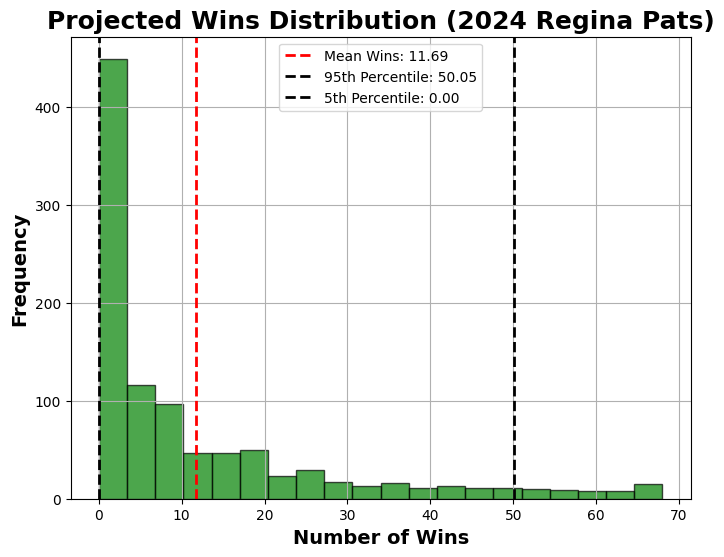

In [ ]:
team_summary = simulate_goals(team_db, gaussian_sim, team_id=212, season_id=281, n_simulations=1000)

In [ ]:
def gaussian_sim2(n_simulations, gp, avg_goals, avg_goals_against, std_dev_goals, std_dev_goals_against, random_factor, all_goals_simulations, all_goals_against_simulations, all_goal_differential_simulations):
    for i in range(n_simulations):
        # Simulate goals scored and goals against for each game
        random_goals_against = - np.random.normal(loc=avg_goals_against, scale=random_factor * std_dev_goals_against, size=gp)
        random_goals = np.random.normal(loc=avg_goals, scale=random_factor * std_dev_goals, size=gp)

        # Clip negative values (since goals can't be negative)
        random_goals = np.clip(random_goals, 0, None)
        random_goals_against = np.clip(random_goals_against, None, 0)

        # Calculate cumulative goals, goals against, and goal differential
        all_goals_simulations[i] = np.cumsum(random_goals)
        all_goals_against_simulations[i] = np.cumsum(random_goals_against)
        all_goal_differential_simulations[i] = all_goals_simulations[i] + all_goals_against_simulations[i]


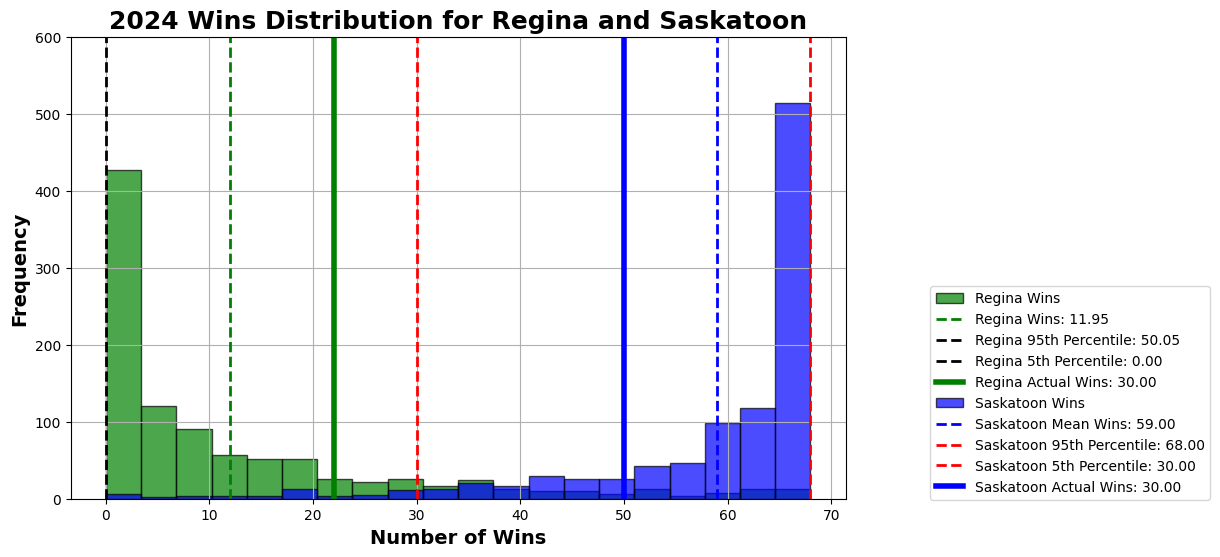

In [ ]:
# Function simulates goals scored, against, differential, and counts wins
# Parameters: team db, both team ids, season id, and num of sims

def simulate_goals_for_two_teams(team_db, func, team_id1, team_id2, season_id, n_simulations=1000):

    team_season_data1 = team_db[(team_db['team_id'] == team_id1) & (team_db['season_id'] == season_id)]
    team_season_data2 = team_db[(team_db['team_id'] == team_id2) & (team_db['season_id'] == season_id)]

    if team_season_data1.empty or team_season_data2.empty:
        print(f"No data found for team_id1={team_id1} and season_id={season_id}, or team_id2={team_id2}.")
        return

    # Number of games played
    gp1 = int(team_season_data1['gp'].iloc[0])
    gp2 = int(team_season_data2['gp'].iloc[0])

    # Mean and standard deviation of goals scored and goals against for both teams
    avg_goals1 = team_season_data1['goals_per_game'].iloc[0]
    std_dev_goals1 = team_season_data1['std_goals_per_season'].iloc[0]
    avg_goals_against1 = team_season_data1['goalsagainst_per_game'].iloc[0]
    std_dev_goals_against1 = team_season_data1['std_goals_against_per_season'].iloc[0]

    avg_goals2 = team_season_data2['goals_per_game'].iloc[0]
    std_dev_goals2 = team_season_data2['std_goals_per_season'].iloc[0]
    avg_goals_against2 = team_season_data2['goalsagainst_per_game'].iloc[0]
    std_dev_goals_against2 = team_season_data2['std_goals_against_per_season'].iloc[0]

    random_factor = 3

    # Storage for simulations for both teams
    all_goals_simulations1 = np.zeros((n_simulations, gp1))
    all_goals_against_simulations1 = np.zeros((n_simulations, gp1))
    all_goal_differential_simulations1 = np.zeros((n_simulations, gp1))
    win_counts1 = np.zeros(n_simulations)

    all_goals_simulations2 = np.zeros((n_simulations, gp2))
    all_goals_against_simulations2 = np.zeros((n_simulations, gp2))
    all_goal_differential_simulations2 = np.zeros((n_simulations, gp2))
    win_counts2 = np.zeros(n_simulations)

    # Call the simulation function for both teams
    func(n_simulations, gp1, avg_goals1, avg_goals_against1, std_dev_goals1, std_dev_goals_against1, random_factor, all_goals_simulations1, all_goals_against_simulations1, all_goal_differential_simulations1)
    func(n_simulations, gp2, avg_goals2, avg_goals_against2, std_dev_goals2, std_dev_goals_against2, random_factor, all_goals_simulations2, all_goals_against_simulations2, all_goal_differential_simulations2)

    # Count wins for both teams based on goal differential
    for i in range(n_simulations):
        win_counts1[i] = np.sum(all_goal_differential_simulations1[i] > 0)
        win_counts2[i] = np.sum(all_goal_differential_simulations2[i] > 0)

    plt.figure(figsize=(10, 6))

    # Plot histogram for team 1
    plt.hist(win_counts1, bins=20, color='green', edgecolor='black', alpha=0.7, label=f'Regina Wins')
    plt.axvline(np.mean(win_counts1), color='green', linestyle='dashed', linewidth=2, label=f'Regina Wins: {np.mean(win_counts1):.2f}')
    plt.axvline(np.percentile(win_counts1, 95), color='black', linestyle='dashed', linewidth=2, label=f'Regina 95th Percentile: {np.percentile(win_counts1, 95):.2f}')
    plt.axvline(np.percentile(win_counts1, 5), color='black', linestyle='dashed', linewidth=2, label=f'Regina 5th Percentile: {np.percentile(win_counts1, 5):.2f}')
    plt.axvline(team_db[team_db['team_id'] == team_id1]['w'].iloc[0], color='green', linewidth=4, label=f'Regina Actual Wins: {np.percentile(win_counts2, 5):.2f}')

    # Plot histogram for team 2
    plt.hist(win_counts2, bins=20, color='blue', edgecolor='black', alpha=0.7, label=f'Saskatoon Wins')
    plt.axvline(np.mean(win_counts2), color='blue', linestyle='dashed', linewidth=2, label=f'Saskatoon Mean Wins: {np.mean(win_counts2):.2f}')
    plt.axvline(np.percentile(win_counts2, 95), color='red', linestyle='dashed', linewidth=2, label=f'Saskatoon 95th Percentile: {np.percentile(win_counts2, 95):.2f}')
    plt.axvline(np.percentile(win_counts2, 5), color='red', linestyle='dashed', linewidth=2, label=f'Saskatoon 5th Percentile: {np.percentile(win_counts2, 5):.2f}')
    plt.axvline(team_db[team_db['team_id'] == team_id2]['w'].iloc[0], color='blue', linewidth=4, label=f'Saskatoon Actual Wins: {np.percentile(win_counts2, 5):.2f}')

    plt.title("2024 Wins Distribution for Regina and Saskatoon", fontsize=18, fontweight="bold")
    plt.xlabel("Number of Wins", fontsize=14, fontweight="bold")
    plt.ylabel("Frequency", fontsize=14, fontweight="bold")
    plt.legend(loc='best', bbox_to_anchor=(1.1, 0.475))
    plt.grid(True)
    plt.ylim([0,600])
    plt.show()

    # Create win summaries for both teams
    win_summary1 = {
        'season_id': season_id,
        'team_id': team_id1,
        'average_wins': np.mean(win_counts1),
        'wins_95_percentile': np.percentile(win_counts1, 95),
        'wins_5_percentile': np.percentile(win_counts1, 5)
    }

    win_summary2 = {
        'season_id': season_id,
        'team_id': team_id2,
        'average_wins': np.mean(win_counts2),
        'wins_95_percentile': np.percentile(win_counts2, 95),
        'wins_5_percentile': np.percentile(win_counts2, 5)
    }

    return win_summary1, win_summary2

win_summary1, win_summary2 = simulate_goals_for_two_teams(team_db, gaussian_sim2, team_id1=212, team_id2=213, season_id=281)

In [ ]:
n_simulations = 1000

team_summary = []

# Iterate over each season
for season_id in team_db['season_id'].unique():
    team_season_data = team_db[team_db['season_id'] == season_id]

    # Iterate over each team in the season
    for team_id in team_season_data['team_id'].unique():
        team_data = team_season_data[team_season_data['team_id'] == team_id]

        if not team_data.empty:
            # Number of games played
            gp = int(team_data['gp'].iloc[0])

            # Real goals for and goals against from the team data
            real_goals_for = team_data['goals_per_game'].iloc[0] * gp
            real_goals_against = team_data['goalsagainst_per_game'].iloc[0] * gp

            # Mean and standard deviation of goals scored and goals against
            avg_goals = team_data['goals_per_game'].iloc[0]
            std_dev_goals = team_data['std_goals_per_season'].iloc[0]

            avg_goals_against = team_data['goalsagainst_per_game'].iloc[0]
            std_dev_goals_against = team_data['std_goals_against_per_season'].iloc[0]

            all_goals_simulations = np.zeros((n_simulations, gp))
            all_goals_against_simulations = np.zeros((n_simulations, gp))

            ramdom_factor = 1

            for i in range(n_simulations):
                # Simulate goals scored and goals against for each game
                random_goals = np.random.normal(loc=avg_goals, scale = ramdom_factor * std_dev_goals, size=gp)
                random_goals_against = np.random.normal(loc=avg_goals_against, scale= ramdom_factor * std_dev_goals_against, size=gp)

                # Clip negative values (since goals can't be negative)
                random_goals = np.clip(random_goals, 0, None)
                random_goals_against = np.clip(random_goals_against, 0, None)

                all_goals_simulations[i] = random_goals
                all_goals_against_simulations[i] = random_goals_against

            cumulative_goals = np.mean(np.cumsum(all_goals_simulations, axis=1), axis=0)
            cumulative_goals_against = np.mean(np.cumsum(all_goals_against_simulations, axis=1), axis=0)
            goal_differential = cumulative_goals - cumulative_goals_against

            if np.isnan(real_goals_for) or np.isnan(real_goals_against) or np.any(np.isnan(cumulative_goals)) or np.any(np.isnan(cumulative_goals_against)):
                continue

            # Calculate MAE for goals for and goals against
            mae_goals_for = mean_absolute_error([real_goals_for], [cumulative_goals[-1]])
            mae_goals_against = mean_absolute_error([real_goals_against], [cumulative_goals_against[-1]])

            # Confidence intervals for the simulations
            lower_goals_for = np.percentile(np.cumsum(all_goals_simulations, axis=1), 2.5, axis=0)
            upper_goals_for = np.percentile(np.cumsum(all_goals_simulations, axis=1), 97.5, axis=0)

            lower_goals_against = np.percentile(np.cumsum(all_goals_against_simulations, axis=1), 2.5, axis=0)
            upper_goals_against = np.percentile(np.cumsum(all_goals_against_simulations, axis=1), 97.5, axis=0)
            goals_for_within_ci = (real_goals_for >= lower_goals_for[-1]) & (real_goals_for <= upper_goals_for[-1])
            goals_against_within_ci = (real_goals_against >= lower_goals_against[-1]) & (real_goals_against <= upper_goals_against[-1])

            # Percentage error for goals for and against
            pct_error_goals_for = 100 * abs(real_goals_for - cumulative_goals[-1]) / real_goals_for if real_goals_for != 0 else np.nan
            pct_error_goals_against = 100 * abs(real_goals_against - cumulative_goals_against[-1]) / real_goals_against if real_goals_against != 0 else np.nan

            team_summary.append({
                'season_id': season_id,
                'team_id': team_id,
                'real_goals_for': real_goals_for,
                'real_goals_against': real_goals_against,
                'expected_goals_for': cumulative_goals[-1],
                'expected_goals_against': cumulative_goals_against[-1],
                'goal_differential': goal_differential[-1],
                'mae_goals_for': mae_goals_for,
                'mae_goals_against': mae_goals_against,
                'lower_goals_for': lower_goals_for[-1],
                'upper_goals_for': upper_goals_for[-1],
                'lower_goals_against': lower_goals_against[-1],
                'upper_goals_against': upper_goals_against[-1],
                'goals_for_within_ci': goals_for_within_ci,
                'goals_against_within_ci': goals_against_within_ci,
                'pct_error_goals_for': pct_error_goals_for,
                'pct_error_goals_against': pct_error_goals_against
            })

team_summary_df = pd.DataFrame(team_summary)

In [ ]:
season_mapping = team_db.drop_duplicates(subset=['season_id'])[['season_id', 'season']]

team_summary_df['season'] = team_summary_df['season_id'].map(
    dict(zip(season_mapping['season_id'], season_mapping['season']))
)

team_summary_df

,season_id,team_id,real_goals_for,real_goals_against,expected_goals_for,expected_goals_against,goal_differential,mae_goals_for,mae_goals_against,lower_goals_for,upper_goals_for,lower_goals_against,upper_goals_against,goals_for_within_ci,goals_against_within_ci,pct_error_goals_for,pct_error_goals_against,season
0,281,213,255.0,163.0,255.485867,165.952742,89.533125,0.485867,2.952742,227.160589,285.281340,141.914297,189.550081,True,True,0.190536,1.811498,2024
1,281,216,286.0,239.0,287.219798,240.647868,46.571930,1.219798,1.647868,258.317226,317.752476,215.603689,270.066247,True,True,0.426503,0.689485,2024
2,281,207,297.0,228.0,298.312540,229.364520,68.948020,1.312540,1.364520,262.698206,333.291128,202.083981,257.528478,True,True,0.441933,0.598473,2024
3,281,206,280.0,231.0,283.702320,232.249842,51.452478,3.702320,1.249842,246.281242,321.744512,203.242049,262.714673,True,True,1.322257,0.541057,2024
4,281,211,213.0,217.0,213.712475,217.995647,-4.283171,0.712475,0.995647,192.858490,235.192769,189.069033,245.552391,True,True,0.334496,0.458823,2024
5,281,201,225.0,244.0,228.318842,245.446509,-17.127667,3.318842,1.446509,198.652767,259.849397,213.591549,277.358724,True,True,1.475041,0.592832,2024
6,281,205,214.0,210.0,217.957900,211.886297,6.071603,3.957900,1.886297,186.359397,250.395759,185.725029,238.325577,True,True,1.849486,0.898237,2024
7,281,209,215.0,221.0,216.434692,221.446174,-5.011482,1.434692,0.446174,188.978079,243.775481,197.564442,244.575936,True,True,0.667299,0.201889,2024
8,281,202,250.0,255.0,253.049393,255.767919,-2.718526,3.049393,0.767919,216.941913,287.728686,227.115579,285.220002,True,True,1.219757,0.301145,2024
9,281,228,227.0,301.0,228.993601,301.296831,-72.303229,1.993601,0.296831,200.223302,258.100654,266.835968,336.835060,True,True,0.878238,0.098615,2024


In [ ]:
def plot_goals_for(team_summary_df):
    fig, ax = plt.subplots(figsize=(8, 6))

    for season_id in team_summary_df['season_id'].unique():
        season_data = team_summary_df[team_summary_df['season_id'] == season_id]
        season_name = season_data['season'].iloc[0]

        # Calculate the percentage of teams with MAE ≤ 12.5% for goals for
        mae_percent_goals_for = (season_data['pct_error_goals_for'] <= 12.5).mean() * 100
        ax.scatter(season_data['mae_goals_for'], season_data['pct_error_goals_for'],
                   label=f'Season {season_name} ({mae_percent_goals_for:.1f}% teams ≤ 12.5% MAE)',
                   alpha=0.6, edgecolors='w', s=100)

    # Add a horizontal line at 12.5% MAE for goals for
    ax.axhline(y=12.5, color='r', linestyle='--', label='12.5% MAE Threshold')
    ax.set_title('Comparison of MAE vs. Percentage Error for Goals For (kappa = 1)', fontsize=18, fontweight='bold')
    ax.set_xlabel('Mean Absolute Error (MAE)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Percentage Error (%)', fontsize=14, fontweight='bold')
    ax.legend(title='Season', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

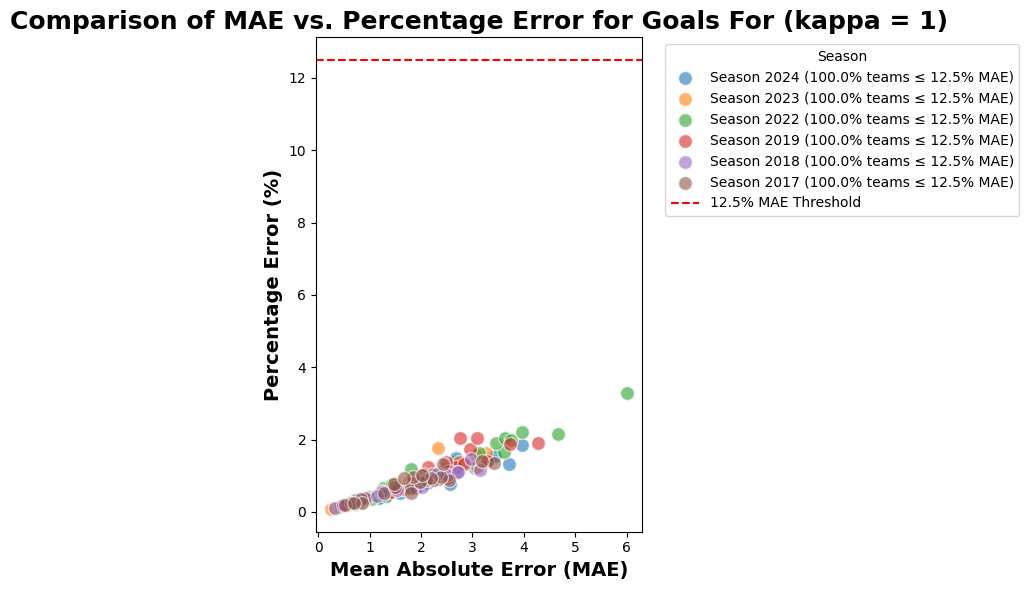

In [ ]:
plot_goals_for(team_summary_df)

In [ ]:
with open('head_to_head_data.pkl', 'rb') as h2h:
    h2h_stats = pickle.load(h2h)

dataframes = []

# Iterate through each key and its associated DataFrame
for key, df in h2h_stats.items():
    df['Team'] = key
    df['Team'] = df['Team'].str.replace('Team_', '', regex=False)
    if 'Opponent_ID' in df.columns:
        df['Opponent_ID'] = df['Opponent_ID'].str.replace('Team_', '', regex=False)
    dataframes.append(df)

combined_df = pd.concat(dataframes, ignore_index=True)

team_id_mapping = {
    'Brandon': '201', 'Calgary': '202', 'Kamloops': '203', 'Kelowna': '204',
    'Lethbridge': '205', 'Medicine Hat': '206', 'Moose Jaw': '207', 'Portland': '208',
    'Prince Albert': '209', 'Prince George': '210', 'Red Deer': '211', 'Regina': '212',
    'Saskatoon': '213', 'Seattle': '214', 'Spokane': '215', 'Swift Current': '216',
    'Tri-City': '217', 'Wenatchee': '222', 'Winnipeg': '222', 'Kootenay': '222',
    'Vancouver': '223', 'Everett': '226', 'Victoria': '227', 'Edmonton': '228'
}

combined_df['team_name'] = combined_df['Team'].map({v: k for k, v in team_id_mapping.items()})
combined_df['games_played_count'] = combined_df['Wins'] + combined_df['Losses'] + combined_df['OT_Losses'] + combined_df['SO_Loss']
combined_df['Team'] = combined_df['Team'].astype(int)
combined_df['Opponent_ID'] = combined_df['Opponent_ID'].astype(int)
combined_df['Season'] = combined_df['Season'].astype(int)
combined_df.columns = combined_df.columns.str.lower()

In [ ]:
team_db.head()
team_db['team_id'].unique()
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4620 entries, 0 to 4619
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   season_id           4620 non-null   int64 
 1   season              4620 non-null   int64 
 2   opponent_id         4620 non-null   int64 
 3   opponent_name       4620 non-null   object
 4   wins                4620 non-null   int64 
 5   losses              4620 non-null   int64 
 6   ot_losses           4620 non-null   int64 
 7   so_loss             4620 non-null   int64 
 8   team                4620 non-null   int64 
 9   team_name           4620 non-null   object
 10  games_played_count  4620 non-null   int64 
dtypes: int64(9), object(2)
memory usage: 397.2+ KB


In [ ]:
combined_df.head()

,season_id,season,opponent_id,opponent_name,wins,losses,ot_losses,so_loss,team,team_name,games_played_count
0,281,2024,202,Calgary,1,2,1,0,201,Brandon,4
1,281,2024,228,Edmonton,3,0,1,0,201,Brandon,4
2,281,2024,226,Everett,0,0,1,0,201,Brandon,1
3,281,2024,203,Kamloops,1,0,0,0,201,Brandon,1
4,281,2024,204,Kelowna,1,0,0,0,201,Brandon,1


In [ ]:
# Extract relevant columns for matchups
matchups = combined_df[['season_id', 'season', 'team', 'opponent_id', 'games_played_count']]

In [ ]:
w1 = 0.75
w2 = 1 - w1

In [ ]:
n_simulations = 100
team_summary = []

# Iterate over each season
for season_id in team_db['season_id'].unique():
    team_season_data = team_db[team_db['season_id'] == season_id]
    season_matchups = matchups[matchups['season_id'] == season_id]

    # Iterate over each team in the season
    for team_id in team_season_data['team_id'].unique():
        team_data = team_season_data[team_season_data['team_id'] == team_id]

        if not team_data.empty:
            # Number of games played
            gp = int(team_data['gp'].iloc[0])
            real_goals_for = team_data['goals_per_game'].iloc[0] * gp
            real_goals_against = team_data['goalsagainst_per_game'].iloc[0] * gp

            # Mean and standard deviation of goals scored and goals against
            avg_goals = team_data['goals_per_game'].iloc[0]
            std_dev_goals = team_data['std_goals_per_season'].iloc[0]
            avg_goals_against = team_data['goalsagainst_per_game'].iloc[0]
            std_dev_goals_against = team_data['std_goals_against_per_season'].iloc[0]

            all_goals_simulations = np.zeros((n_simulations, gp))
            all_goals_against_simulations = np.zeros((n_simulations, gp))

            # Iterate over matchups
            for _, matchup in season_matchups[season_matchups['team'] == team_id].iterrows():
                opponent_id = matchup['opponent_id']
                games_played = matchup['games_played_count']
                opponent_data = team_season_data[team_season_data['team_id'] == opponent_id]

                if not opponent_data.empty:
                    avg_opponent_goals_for = opponent_data['goals_per_game'].iloc[0]
                    avg_opponent_goals_against = opponent_data['goalsagainst_per_game'].iloc[0]

                    # Weighted average for team 1's goals for and team 2's goals against
                    weighted_goals_for = w1 * avg_goals + w2 * avg_opponent_goals_against
                    weighted_goals_against = w1 * avg_goals_against + w2 * avg_opponent_goals_for

                    # Simulate the goals scored and goals against for the number of games played in this matchup
                    random_goals = np.random.normal(loc=weighted_goals_for, scale=2 * std_dev_goals, size=games_played)
                    random_goals_against = np.random.normal(loc=weighted_goals_against, scale=2 * std_dev_goals_against, size=games_played)

                    # Clip negative values (since goals can't be negative)
                    random_goals = np.clip(random_goals, 0, None)
                    random_goals_against = np.clip(random_goals_against, 0, None)

                    all_goals_simulations[:, :games_played] += random_goals
                    all_goals_against_simulations[:, :games_played] += random_goals_against

            cumulative_goals = np.mean(np.cumsum(all_goals_simulations, axis=1), axis=0)
            cumulative_goals_against = np.mean(np.cumsum(all_goals_against_simulations, axis=1), axis=0)
            goal_differential = cumulative_goals - cumulative_goals_against
            if np.isnan(real_goals_for) or np.isnan(real_goals_against) or np.any(np.isnan(cumulative_goals)) or np.any(np.isnan(cumulative_goals_against)):
                continue

            # Calculate MAE for goals for and goals against
            mae_goals_for = mean_absolute_error([real_goals_for], [cumulative_goals[-1]])
            mae_goals_against = mean_absolute_error([real_goals_against], [cumulative_goals_against[-1]])

            # Percentage error for goals for and against
            pct_error_goals_for = 100 * abs(real_goals_for - cumulative_goals[-1]) / real_goals_for if real_goals_for != 0 else np.nan
            pct_error_goals_against = 100 * abs(real_goals_against - cumulative_goals_against[-1]) / real_goals_against if real_goals_against != 0 else np.nan

            team_summary.append({
                'season_id': season_id,
                'team_id': team_id,
                'real_goals_for': real_goals_for,
                'real_goals_against': real_goals_against,
                'expected_goals_for': cumulative_goals[-1],
                'expected_goals_against': cumulative_goals_against[-1],
                'goal_differential': goal_differential[-1],
                'mae_goals_for': mae_goals_for,
                'mae_goals_against': mae_goals_against,
                'pct_error_goals_for': pct_error_goals_for,
                'pct_error_goals_against': pct_error_goals_against
            })

team_summary_df = pd.DataFrame(team_summary)

In [ ]:
# Filter the season_mapping to include only season_id = 281
season_mapping = team_db.drop_duplicates(subset=['season_id'])[['season_id', 'season']]
season_mapping = season_mapping[season_mapping['season_id'] == 281]
team_summary_df['season'] = team_summary_df['season_id'].map(
    dict(zip(season_mapping['season_id'], season_mapping['season']))
)

team_summary_df


,season_id,team_id,real_goals_for,real_goals_against,expected_goals_for,expected_goals_against,goal_differential,mae_goals_for,mae_goals_against,pct_error_goals_for,pct_error_goals_against,season
0,281,213,255.0,163.0,250.042446,205.929863,44.112583,4.957554,42.929863,1.944139,26.337339,2024.0
1,281,216,286.0,239.0,246.592731,280.867882,-34.275151,39.407269,41.867882,13.778765,17.517942,2024.0
2,281,207,297.0,228.0,326.763284,266.291476,60.471808,29.763284,38.291476,10.021308,16.794507,2024.0
3,281,206,280.0,231.0,289.704721,257.396016,32.308705,9.704721,26.396016,3.465972,11.426847,2024.0
4,281,211,213.0,217.0,222.671109,243.818778,-21.147669,9.671109,26.818778,4.540427,12.358884,2024.0
5,281,201,225.0,244.0,237.971351,279.795998,-41.824647,12.971351,35.795998,5.765045,14.670491,2024.0
6,281,205,214.0,210.0,204.814271,213.842926,-9.028655,9.185729,3.842926,4.292397,1.829965,2024.0
7,281,209,215.0,221.0,221.673587,257.139548,-35.465961,6.673587,36.139548,3.103994,16.352737,2024.0
8,281,202,250.0,255.0,266.380151,300.855088,-34.474937,16.380151,45.855088,6.552060,17.982388,2024.0
9,281,228,227.0,301.0,229.248044,301.102418,-71.854374,2.248044,0.102418,0.990328,0.034026,2024.0


In [ ]:
team_summary_df

,season_id,team_id,real_goals_for,real_goals_against,expected_goals_for,expected_goals_against,goal_differential,mae_goals_for,mae_goals_against,pct_error_goals_for,pct_error_goals_against,season
0,281,213,255.0,163.0,250.042446,205.929863,44.112583,4.957554,42.929863,1.944139,26.337339,2024.0
1,281,216,286.0,239.0,246.592731,280.867882,-34.275151,39.407269,41.867882,13.778765,17.517942,2024.0
2,281,207,297.0,228.0,326.763284,266.291476,60.471808,29.763284,38.291476,10.021308,16.794507,2024.0
3,281,206,280.0,231.0,289.704721,257.396016,32.308705,9.704721,26.396016,3.465972,11.426847,2024.0
4,281,211,213.0,217.0,222.671109,243.818778,-21.147669,9.671109,26.818778,4.540427,12.358884,2024.0
5,281,201,225.0,244.0,237.971351,279.795998,-41.824647,12.971351,35.795998,5.765045,14.670491,2024.0
6,281,205,214.0,210.0,204.814271,213.842926,-9.028655,9.185729,3.842926,4.292397,1.829965,2024.0
7,281,209,215.0,221.0,221.673587,257.139548,-35.465961,6.673587,36.139548,3.103994,16.352737,2024.0
8,281,202,250.0,255.0,266.380151,300.855088,-34.474937,16.380151,45.855088,6.552060,17.982388,2024.0
9,281,228,227.0,301.0,229.248044,301.102418,-71.854374,2.248044,0.102418,0.990328,0.034026,2024.0


In [ ]:
# plot_mae_vs_pct_error(team_summary_df)

In [ ]:
# Calculate the average MAE for goals for and goals against
avg_mae_goals_for = team_summary_df['mae_goals_for'].mean()
avg_mae_goals_against = team_summary_df['mae_goals_against'].mean()

print(f"Average MAE for Goals For: {avg_mae_goals_for:.2f}")
print(f"Average MAE for Goals Against: {avg_mae_goals_against:.2f}")

Average MAE for Goals For: 34.33
Average MAE for Goals Against: 31.62


In [ ]:
n_simulations = 100

team_summary = []
w1_values = np.linspace(0, 1, 11)

# Set the random seed for reproducibility
np.random.seed(42)

# Iterate over each w1 value and calculate the corresponding w2
for w1 in w1_values:
    w2 = 1 - w1

    # DataFrame to store the MSE results for each w1, w2 combination
    mse_goals_for_list = []
    mse_goals_against_list = []

    # Filter the data for season_id = 281
    team_db_281 = team_db[team_db['season_id'] == 281]
    matchups_281 = matchups[matchups['season_id'] == 281]

    # Iterate over each season (only season_id = 281)
    for season_id in [281]:
        team_season_data = team_db_281
        season_matchups = matchups_281

        # Iterate over each team in the season
        for team_id in team_season_data['team_id'].unique():
            team_data = team_season_data[team_season_data['team_id'] == team_id]
            if not team_data.empty:
                # Number of games played
                gp = int(team_data['gp'].iloc[0])

                real_goals_for = team_data['goals_per_game'].iloc[0] * gp
                real_goals_against = team_data['goalsagainst_per_game'].iloc[0] * gp

                # Mean and standard deviation of goals scored and goals against
                avg_goals = team_data['goals_per_game'].iloc[0]
                std_dev_goals = team_data['std_goals_per_season'].iloc[0]
                avg_goals_against = team_data['goalsagainst_per_game'].iloc[0]
                std_dev_goals_against = team_data['std_goals_against_per_season'].iloc[0]

                all_goals_simulations = np.zeros((n_simulations, gp))
                all_goals_against_simulations = np.zeros((n_simulations, gp))

                # Iterate over matchups
                for _, matchup in season_matchups[season_matchups['team'] == team_id].iterrows():
                    opponent_id = matchup['opponent_id']
                    games_played = matchup['games_played_count']
                    opponent_data = team_season_data[team_season_data['team_id'] == opponent_id]

                    if not opponent_data.empty:
                        avg_opponent_goals_for = opponent_data['goals_per_game'].iloc[0]
                        avg_opponent_goals_against = opponent_data['goalsagainst_per_game'].iloc[0]

                        weighted_goals_for = w1 * avg_goals + w2 * avg_opponent_goals_against
                        weighted_goals_against = w1 * avg_goals_against + w2 * avg_opponent_goals_for

                        random_factor = 3

                        # Simulate the goals scored and goals against for the number of games played in this matchup
                        random_goals = np.random.normal(loc=weighted_goals_for, scale=random_factor * std_dev_goals, size=games_played)
                        random_goals_against = np.random.normal(loc=weighted_goals_against, scale=random_factor * std_dev_goals_against, size=games_played)

                        # Clip negative values (since goals can't be negative)
                        random_goals = np.clip(random_goals, 0, None)
                        random_goals_against = np.clip(random_goals_against, 0, None)

                        all_goals_simulations[:, :games_played] += random_goals
                        all_goals_against_simulations[:, :games_played] += random_goals_against

                cumulative_goals = np.mean(np.cumsum(all_goals_simulations, axis=1), axis=0)
                cumulative_goals_against = np.mean(np.cumsum(all_goals_against_simulations, axis=1), axis=0)
                goal_differential = cumulative_goals - cumulative_goals_against
                if np.isnan(real_goals_for) or np.isnan(real_goals_against) or np.any(np.isnan(cumulative_goals)) or np.any(np.isnan(cumulative_goals_against)):
                    continue

                # Calculate MAE for goals for and goals against
                mae_goals_for = mean_absolute_error([real_goals_for], [cumulative_goals[-1]])
                mae_goals_against = mean_absolute_error([real_goals_against], [cumulative_goals_against[-1]])
                mse_goals_for_list.append(mae_goals_for)
                mse_goals_against_list.append(mae_goals_against)

    avg_mae_goals_for = np.mean(mse_goals_for_list)
    avg_mae_goals_against = np.mean(mse_goals_against_list)

    # Store the results for this w1 and w2 combination
    team_summary.append({
        'w1': w1,
        'w2': w2,
        'avg_mae_goals_for': avg_mae_goals_for,
        'avg_mae_goals_against': avg_mae_goals_against
    })

team_summary_df = pd.DataFrame(team_summary)

team_summary_df


,w1,w2,avg_mae_goals_for,avg_mae_goals_against
0,0.0,1.0,83.066655,68.013094
1,0.1,0.9,73.707192,45.793395
2,0.2,0.8,72.030384,68.938561
3,0.3,0.7,55.130105,67.129979
4,0.4,0.6,72.732490,79.984835
5,0.5,0.5,75.204933,71.903966
6,0.6,0.4,63.761755,66.423236
7,0.7,0.3,73.487500,55.713981
8,0.8,0.2,62.889156,71.519592
9,0.9,0.1,65.197022,52.608654


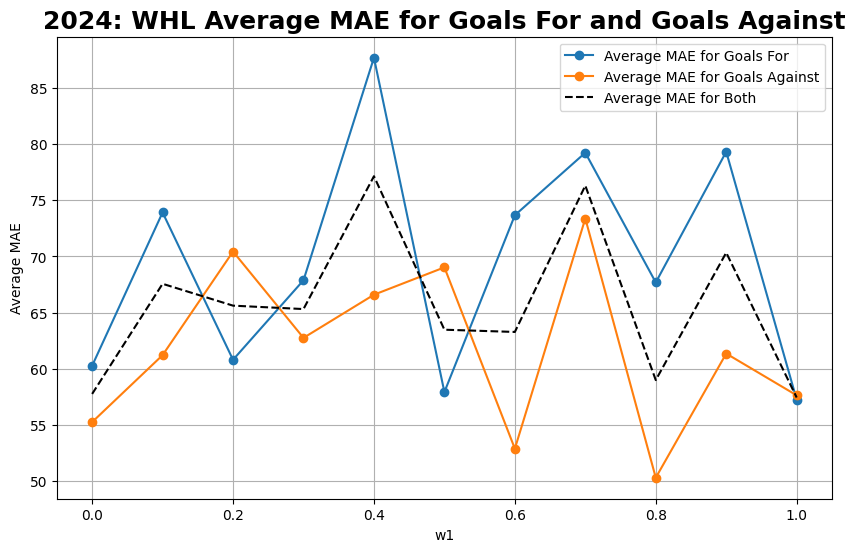

In [ ]:
# Calculate the average of the two error values (Goals For and Goals Against)
team_summary_df['avg_mae_both'] = (team_summary_df['avg_mae_goals_for'] + team_summary_df['avg_mae_goals_against']) / 2

plt.figure(figsize=(10, 6))
plt.plot(team_summary_df['w1'], team_summary_df['avg_mae_goals_for'], label='Average MAE for Goals For', marker='o')
plt.plot(team_summary_df['w1'], team_summary_df['avg_mae_goals_against'], label='Average MAE for Goals Against', marker='o')
plt.plot(team_summary_df['w1'], team_summary_df['avg_mae_both'], label='Average MAE for Both', linestyle='--', color='black')
plt.title('2024: WHL Average MAE for Goals For and Goals Against', fontsize=18, fontweight='bold')
plt.xlabel('w1')
plt.ylabel('Average MAE')
plt.legend()
plt.grid(True)
plt.show()

# Section 3: Trade Stats

In [ ]:
# This section takes 4 minutes to run

full_df_sorted['date'] = pd.to_datetime(full_df_sorted['date'], errors='coerce')
trade_stats = []

# Iterate over each trade in trades_db
for _, trade in trades_db.iterrows():
    trade_date = trade['date']
    team_id = trade['team_id']
    traded_team_id = trade['traded_team_id']

    # Collect all assets (players) involved in the trade for both teams
    team_1_assets = [trade[f'asset_{i}_team_1'] for i in range(1, 7) if pd.notna(trade[f'asset_{i}_team_1'])]
    team_2_assets = [trade[f'asset_{i}_team_2'] for i in range(1, 15) if pd.notna(trade[f'asset_{i}_team_2'])]

    players_in_trade = team_1_assets + team_2_assets
    for player_name in players_in_trade:
        player_name = player_name.lower()

        # Find the player entry in full_df_sorted (considering player_name or last_name)
        player_data = full_df_sorted[full_df_sorted['player_name'].str.lower() == player_name]

        if not player_data.empty:
            player_season = player_data['season'].iloc[0]
            team_before = full_df_sorted[
                (full_df_sorted['team_id'] == team_id) &
                (full_df_sorted['season'] == player_season) &
                (full_df_sorted['date'] < trade_date)
            ]

            team_after = full_df_sorted[
                (full_df_sorted['team_id'] == team_id) &
                (full_df_sorted['season'] == player_season) &
                (full_df_sorted['date'] >= trade_date)
            ]

            # Calculate average goals per game and wins before and after the trade
            avg_goals_before = team_before['goals'].mean() if team_before.shape[0] > 0 else 0
            avg_wins_before = team_before[team_before['game_result'] == 'W'].shape[0] / team_before.shape[0] if team_before.shape[0] > 0 else 0
            avg_goals_after = team_after['goals'].mean() if team_after.shape[0] > 0 else 0
            avg_wins_after = team_after[team_after['game_result'] == 'W'].shape[0] / team_after.shape[0] if team_after.shape[0] > 0 else 0

            # Store the stats in a dictionary
            trade_stats.append({
                'trade_date': trade_date,
                'team_id': team_id,
                'traded_team_id': traded_team_id,
                'player_name': player_name,
                'avg_goals_before': avg_goals_before,
                'avg_wins_before': avg_wins_before,
                'avg_goals_after': avg_goals_after,
                'avg_wins_after': avg_wins_after
            })

trade_stats_df = pd.DataFrame(trade_stats)

# Section 4: Visualization of Trade Success

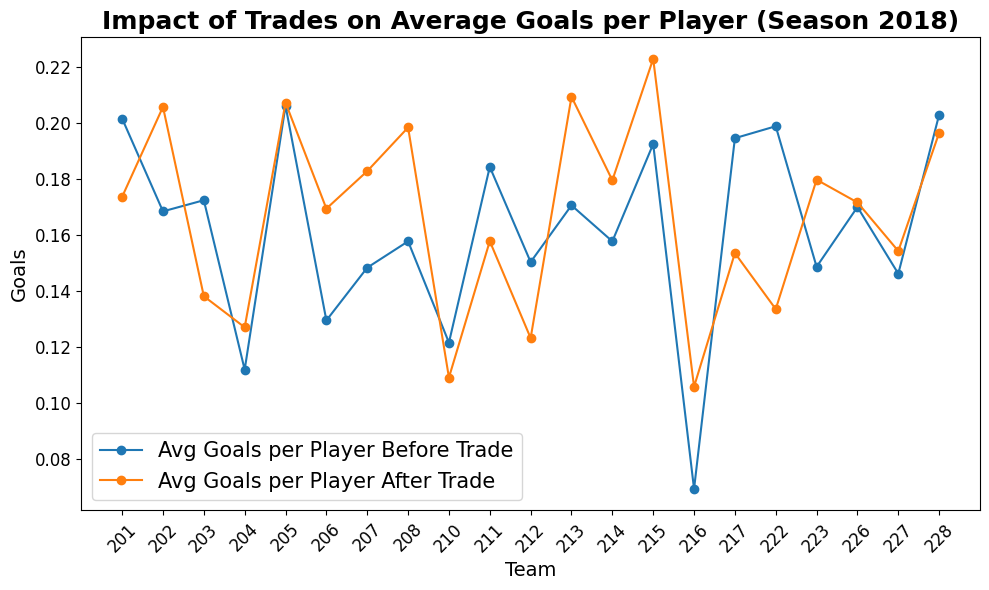

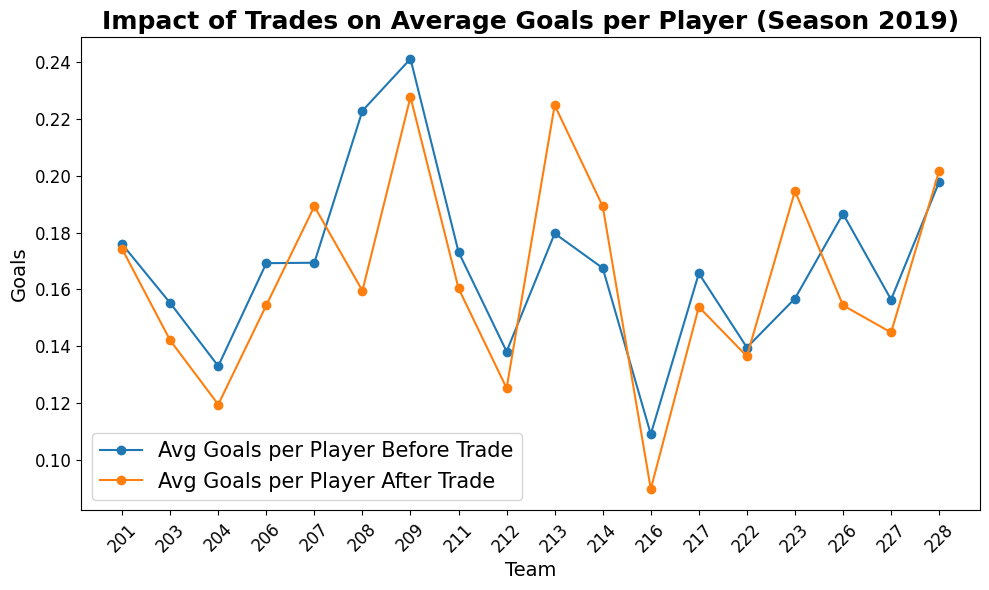

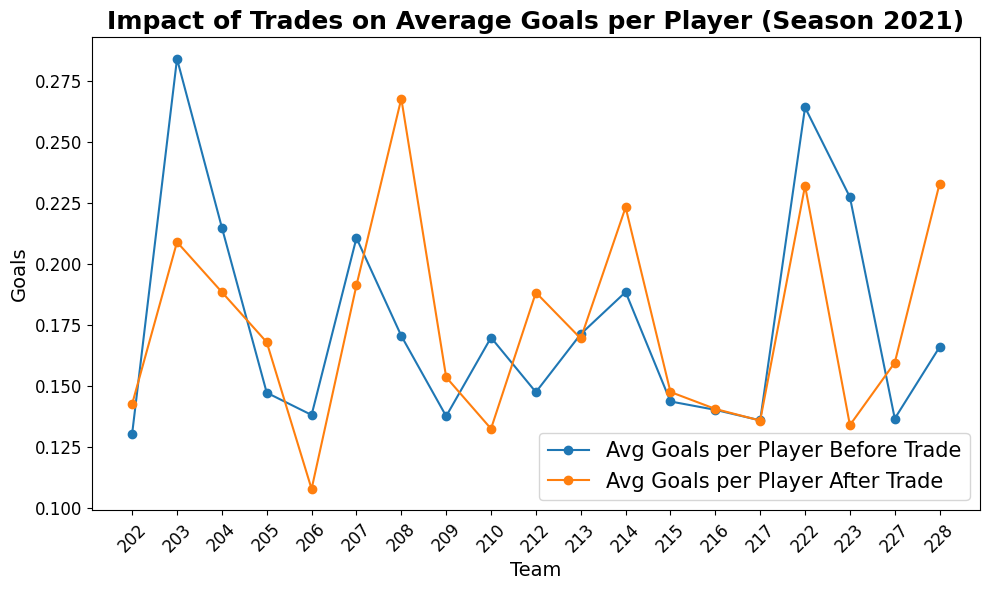

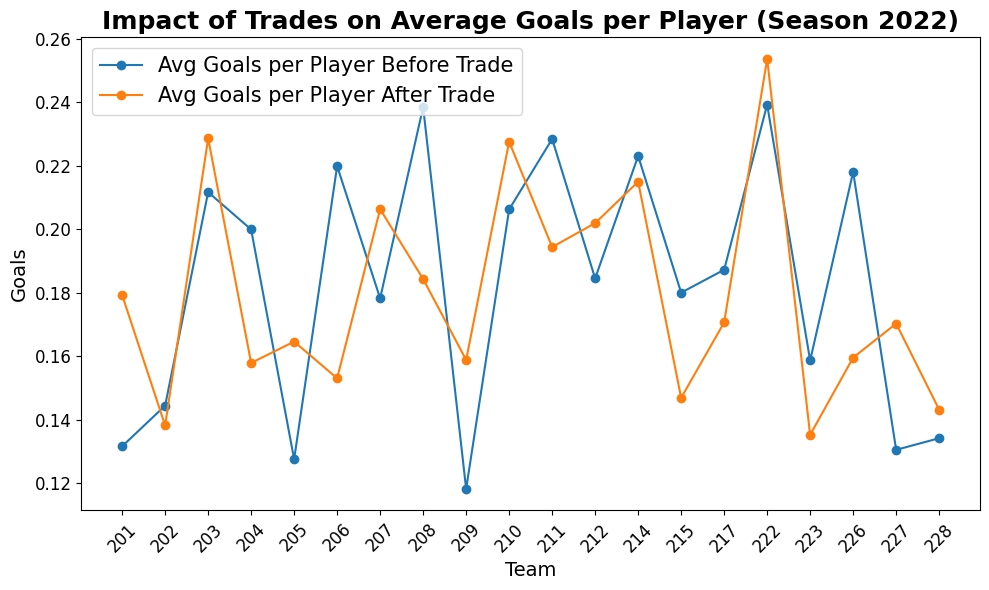

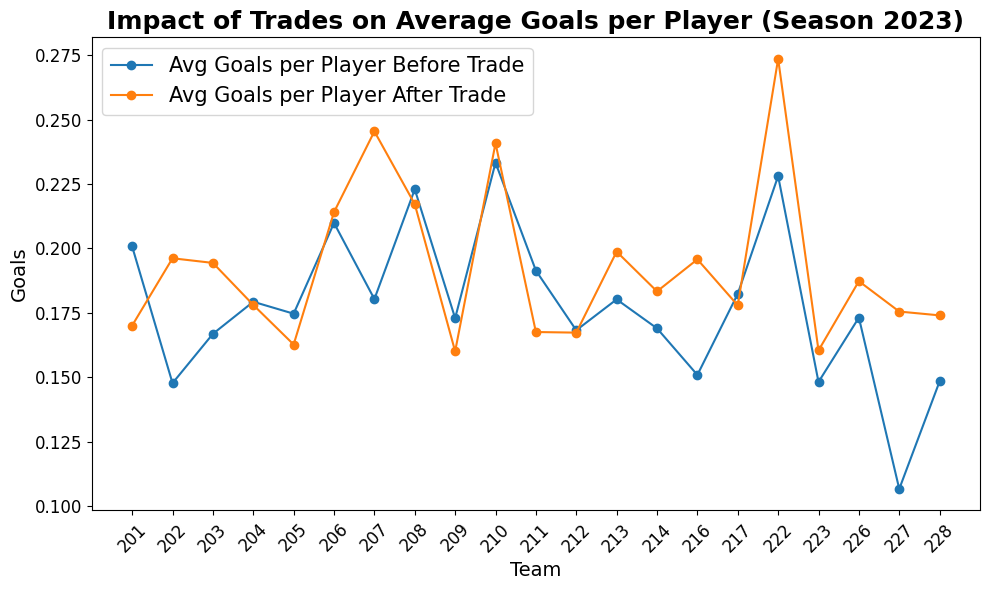

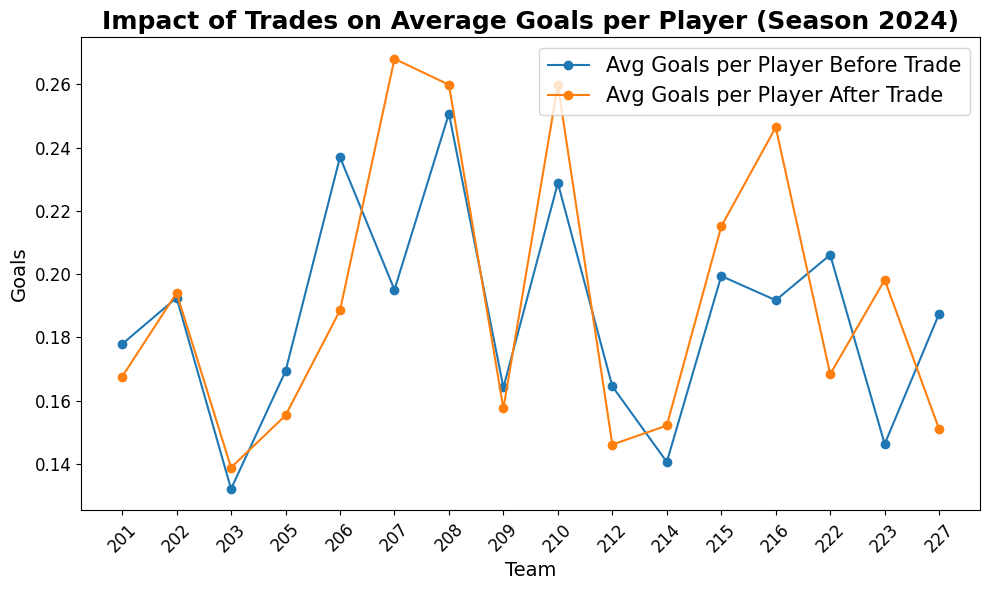

In [ ]:
# Ensure trade_date column is in datetime format and extract 'season'
trade_stats_df['trade_date'] = pd.to_datetime(trade_stats_df['trade_date'])
trade_stats_df['season'] = trade_stats_df['trade_date'].dt.year  # Use year as a proxy for the season

trade_stats_df = trade_stats_df[
    ~((trade_stats_df['avg_goals_before'] == 0) & (trade_stats_df['avg_wins_before'] == 0)) &
    ~((trade_stats_df['avg_goals_after'] == 0) & (trade_stats_df['avg_wins_after'] == 0))
]

# Loop through each season and generate graphs
seasons = trade_stats_df['season'].unique()

for season in seasons:
    season_data = trade_stats_df[trade_stats_df['season'] == season]
    team_performance = season_data.groupby('team_id')[['avg_goals_before', 'avg_goals_after']].mean()

    plt.figure(figsize=(10, 6))
    plt.plot(team_performance['avg_goals_before'], label='Avg Goals per Player Before Trade', marker='o')
    plt.plot(team_performance['avg_goals_after'], label='Avg Goals per Player After Trade', marker='o')
    plt.title(f'Impact of Trades on Average Goals per Player (Season {season})', fontsize=18, fontweight='bold')
    plt.xlabel('Team', fontsize=14)
    plt.ylabel('Goals', fontsize=14)
    plt.xticks(range(len(team_performance)), team_performance.index, rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=15)
    plt.tight_layout()
    plt.show()

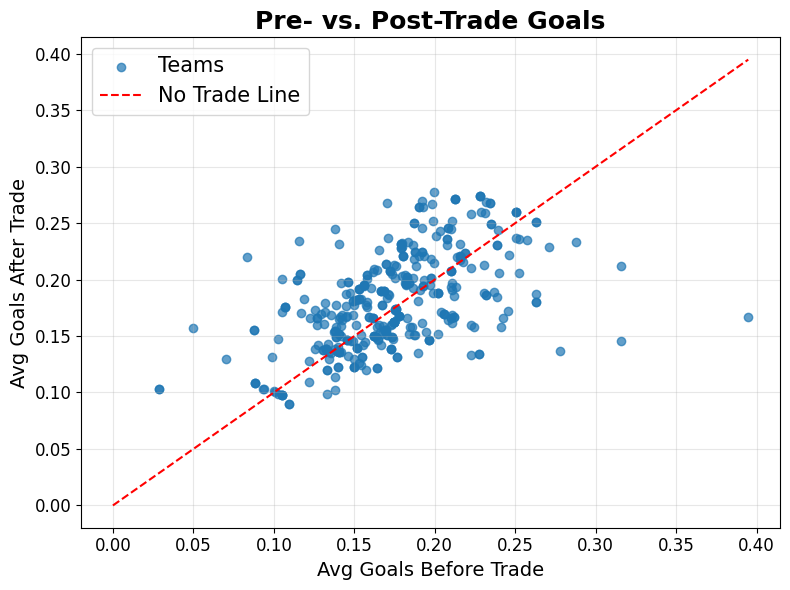

In [ ]:
# Not to be used in the final paper

# Scatter plot of avg_goals_before vs avg_goals_after
plt.figure(figsize=(8, 6))
plt.scatter(trade_stats_df['avg_goals_before'], trade_stats_df['avg_goals_after'], alpha=0.7, label='Teams')
plt.plot([0, max(trade_stats_df['avg_goals_before'].max(), trade_stats_df['avg_goals_after'].max())],
         [0, max(trade_stats_df['avg_goals_before'].max(), trade_stats_df['avg_goals_after'].max())],
         color='red', linestyle='--', label='No Trade Line')
plt.title('Pre- vs. Post-Trade Goals', fontsize=18, fontweight='bold')
plt.xlabel('Avg Goals Before Trade', fontsize=14)
plt.ylabel('Avg Goals After Trade', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=15)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

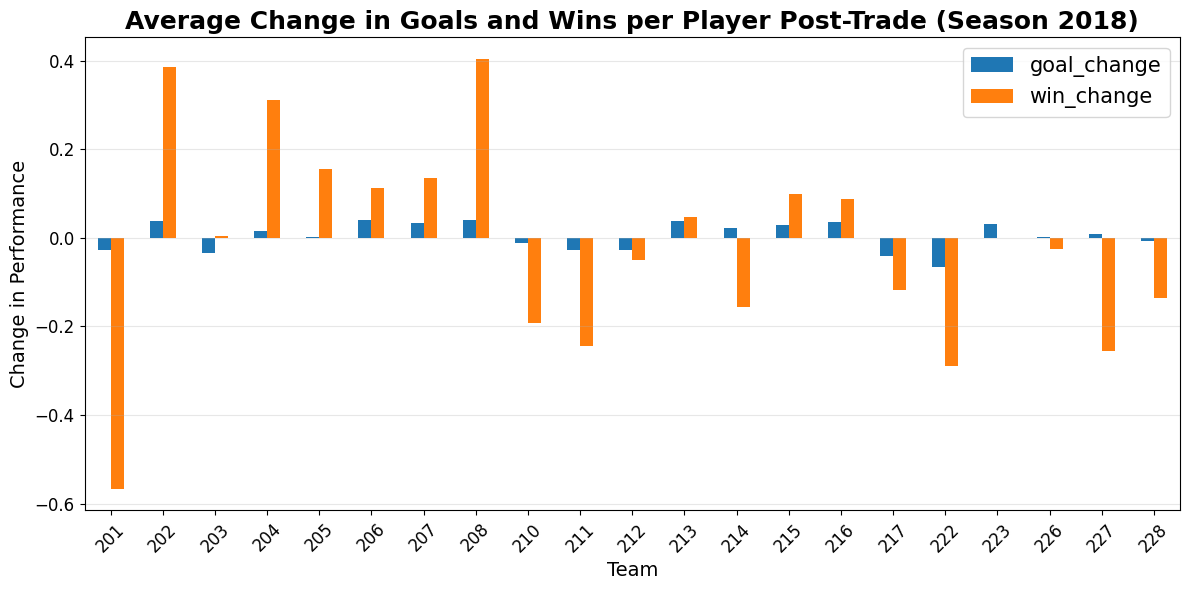

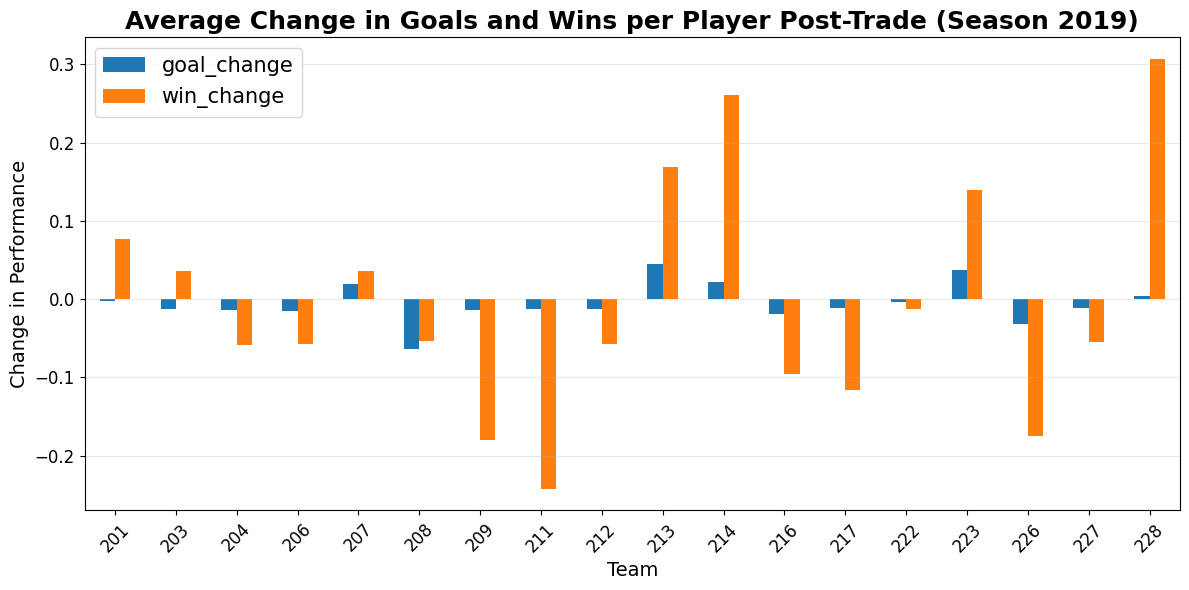

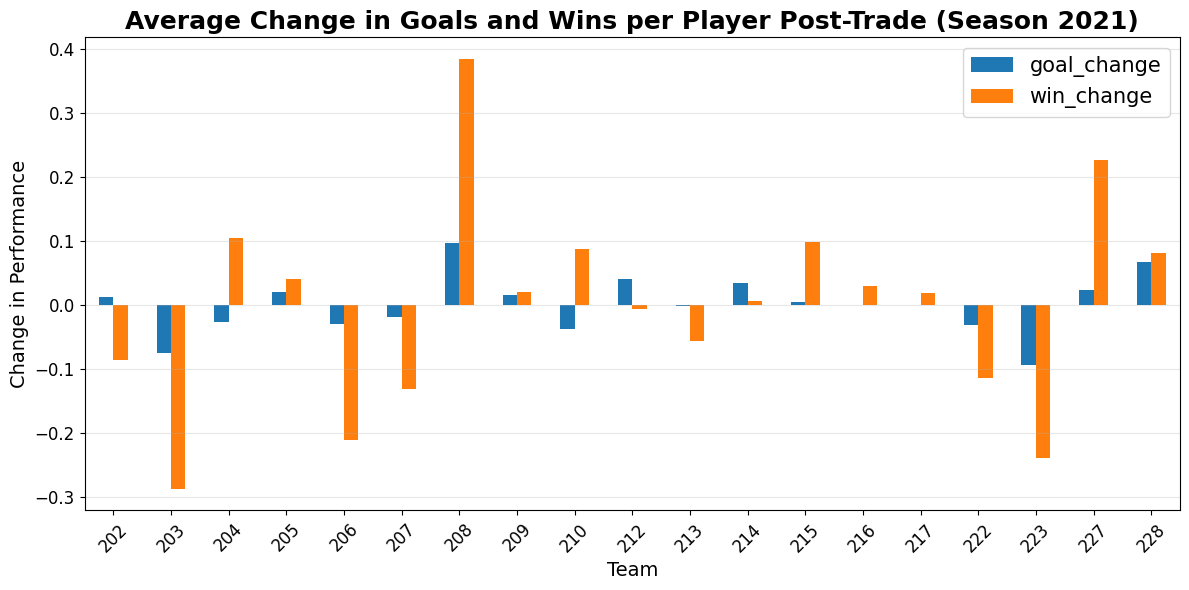

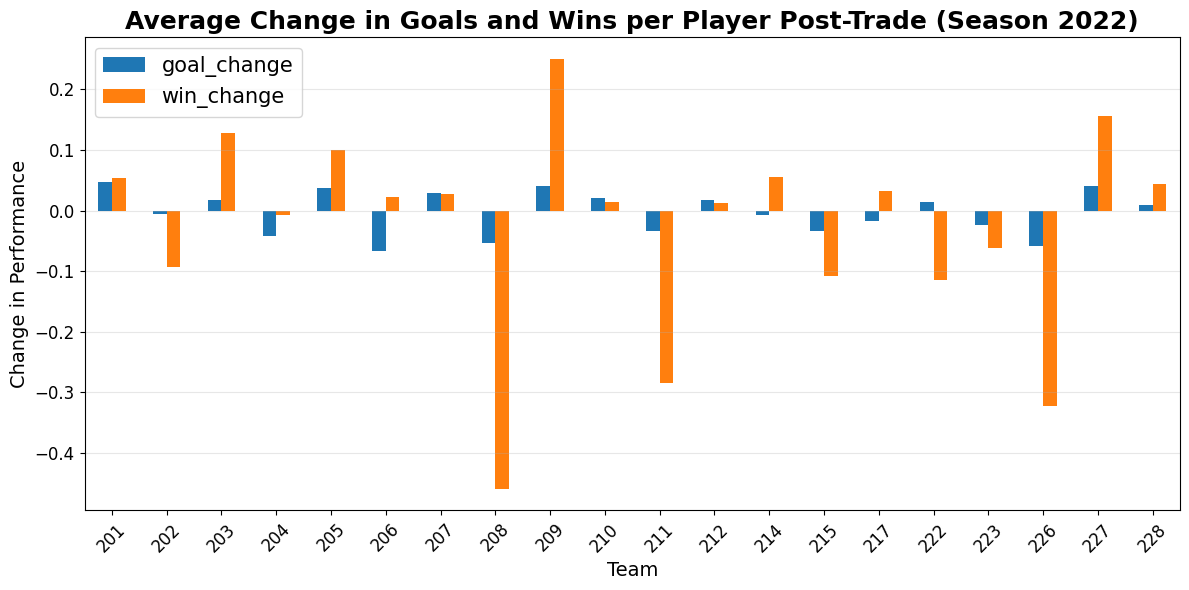

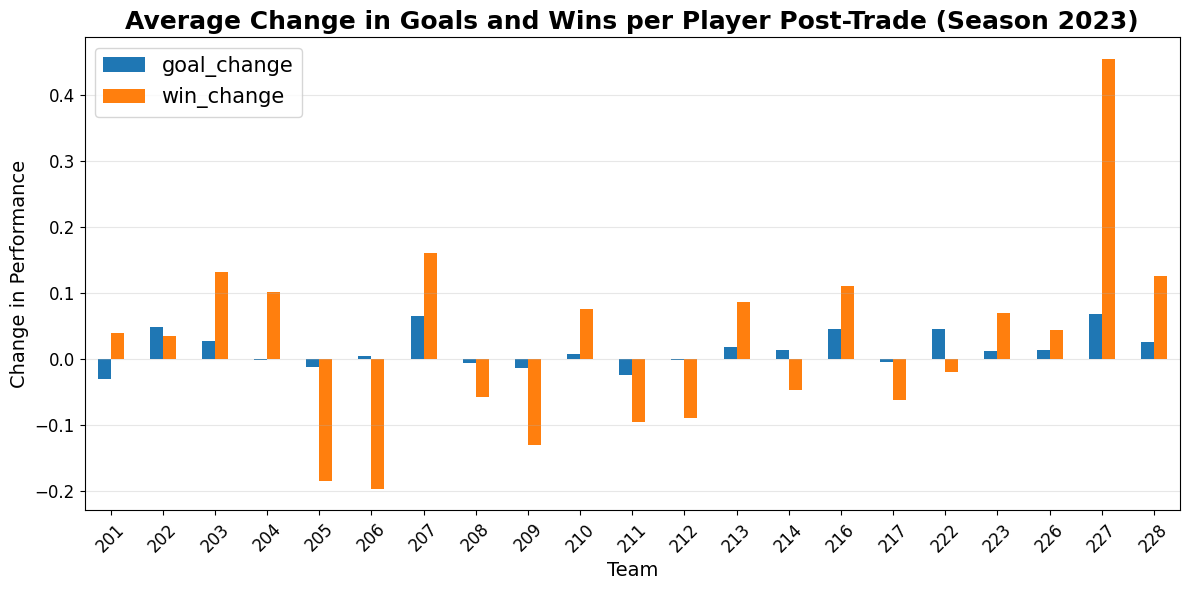

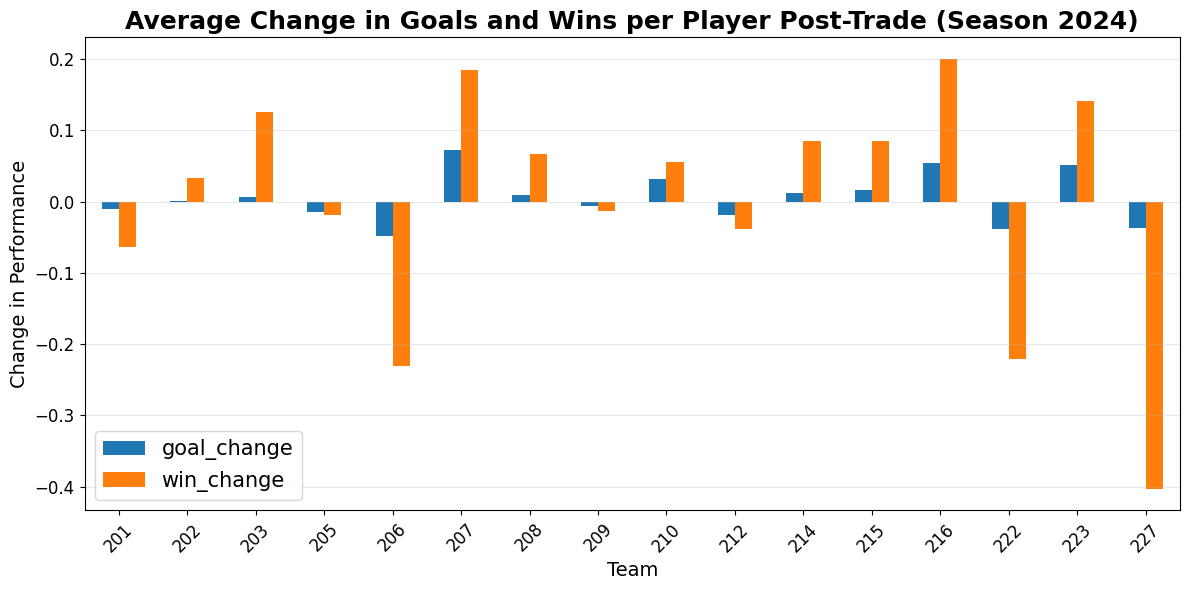

In [ ]:
trade_stats_df['trade_date'] = pd.to_datetime(trade_stats_df['trade_date'])
trade_stats_df['season'] = trade_stats_df['trade_date'].dt.year

# Calculate changes in goals and wins
trade_stats_df['goal_change'] = trade_stats_df['avg_goals_after'] - trade_stats_df['avg_goals_before']
trade_stats_df['win_change'] = trade_stats_df['avg_wins_after'] - trade_stats_df['avg_wins_before']

seasons = trade_stats_df['season'].unique()

for season in seasons:
    season_data = trade_stats_df[trade_stats_df['season'] == season]
    team_changes = season_data.groupby('team_id')[['goal_change', 'win_change']].mean()

    team_changes.plot(kind='bar', figsize=(12, 6))
    plt.title(f'Average Change in Goals and Wins per Player Post-Trade (Season {season})', fontsize=18, fontweight='bold')
    plt.xlabel('Team', fontsize=14)
    plt.ylabel('Change in Performance', fontsize=14)
    plt.xticks(fontsize=12, rotation=45)
    plt.yticks(fontsize=12)
    plt.grid(axis='y', alpha=0.3)
    plt.legend(fontsize=15)
    plt.tight_layout()
    plt.show()

# Section 5: Generating Player Ratings

In [ ]:
from sklearn.ensemble import RandomForestRegressor

player_metrics = pd.read_pickle('whl_player_stats.pkl')

# TO DO: MAKE TARGET VARIABLE DIFFERENT

# Player stats as features
features = ['G', 'A', 'PIM']
target = '+/-'

# Convert target variable to numeric
player_metrics['+/-'] = pd.to_numeric(player_metrics['+/-'], errors='coerce')
player_metrics_clean = player_metrics.dropna(subset=features + [target])

X = player_metrics_clean[features]
y = player_metrics_clean[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

# Feature importance
player_feature_importance = dict(zip(features, rf_model.feature_importances_))
print("Feature Importance:")
print(player_feature_importance)

Feature Importance:
{'G': 0.23374911710233293, 'A': 0.409929520468951, 'PIM': 0.356321362428716}


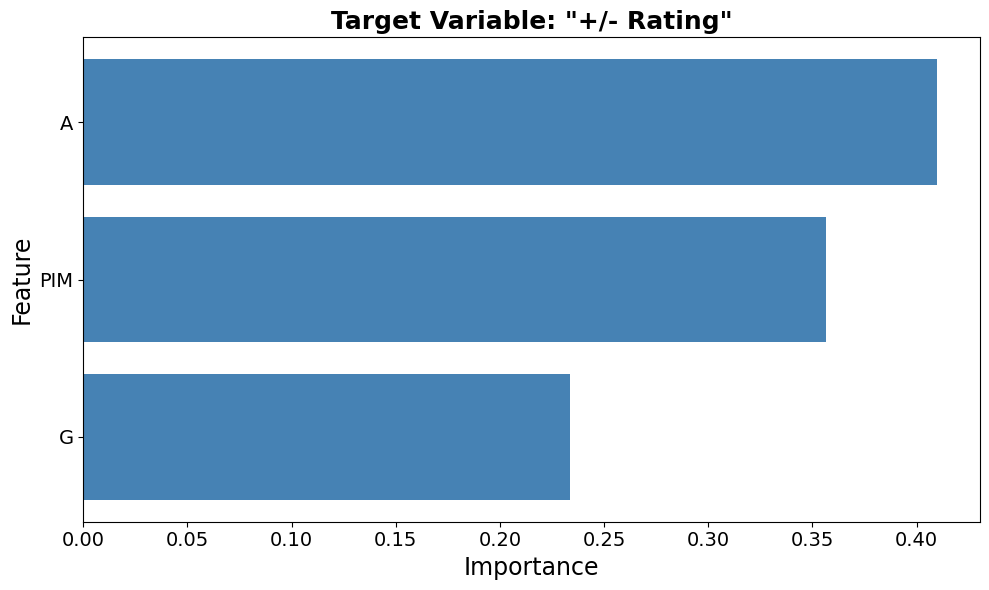

In [ ]:
importance_df = pd.DataFrame(
    list(player_feature_importance.items()),
    columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance', fontsize=17)
plt.ylabel('Feature', fontsize=17)
plt.title('Target Variable: "+/- Rating"', fontsize=18, fontweight='bold')
plt.gca().invert_yaxis()
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
goalie_stats_clean = pd.read_pickle('whl_goalie_stats.pkl')

# 2 points for win, 1 point for an OT loss
goalie_stats_clean['Points_Earned'] = (
    2 * pd.to_numeric(goalie_stats_clean['W'], errors='coerce') +
    1 * pd.to_numeric(goalie_stats_clean['OTL'], errors='coerce')
)

features = ['SV%', 'GAA']
target = 'Points_Earned'

X = goalie_stats_clean[features]
y = goalie_stats_clean[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

goalie_feature_importance = dict(zip(features, rf_model.feature_importances_))
print("Feature Importance:")
print(goalie_feature_importance)

Feature Importance:
{'SV%': 0.620577772690551, 'GAA': 0.3794222273094491}


In [ ]:
# Now, let's actually assign the player rankings
# Parameters: player DF, feature importance coefficients, features, output

def assign_player_rating(player_df, feature_importance, features, output_column='Player_Rating'):

    for feature in features:
        player_df[feature] = pd.to_numeric(player_df[feature], errors='coerce')

    player_df = player_df.dropna(subset=features)

    # Create the Player_Rating column by summing the weighted values of the features
    player_df[output_column] = sum(
        player_df[feature] * coefficient for feature, coefficient in feature_importance.items() if feature in features
    )

    return player_df

# Assign player ratings for players
player_metrics = assign_player_rating(
    player_df=player_metrics,
    feature_importance=player_feature_importance,
    features=['G', 'A', 'GW', 'PIM', 'PP', 'PPA'],
    output_column='Player_Rating'
)

# Assign player ratings for goalies
goalie_stats_clean = assign_player_rating(
    player_df=goalie_stats_clean,
    feature_importance=goalie_feature_importance,
    features=['SV%', 'GAA', 'SO%'],
    output_column='Player_Rating'
)

print("Player Ratings (Skaters):")
print(player_metrics[['Player', 'Season', 'Player_Rating']].head())

print("\nPlayer Ratings (Goalies):")
print(goalie_stats_clean[['Goalie', 'Season', 'Player_Rating']].head())

Player Ratings (Skaters):
          Player Season  Player_Rating
0   Brett Hyland   2024      43.134243
1  Rylen Roersma   2024      43.769514
2  Roger McQueen   2024      35.022685
3   Dominik Petr   2024      21.152903
4   Jayden Wiens   2024      26.103637

Player Ratings (Goalies):
               Goalie Season  Player_Rating
0    Carson Bjarnason   2024       1.704925
1         Ethan Eskit   2024       2.082839
2      Nicholas Jones   2024       3.121302
5  Ethan Buenaventura   2024       1.922578
6        Alex Garrett   2024       1.980945


In [ ]:
from sklearn.preprocessing import MinMaxScaler

def drop_outliers_and_normalize(goalie_df, rating_column='Player_Rating', scaled_column='Normalized_Rating'):
    # Drop outliers where the rating is above 10
    goalie_df = goalie_df[goalie_df[rating_column] <= 10]

    scaler = MinMaxScaler()
    goalie_df[scaled_column] = scaler.fit_transform(goalie_df[[rating_column]]) * 15

    return goalie_df

# Apply outlier removal, normalization, and scaling to goalie_stats_clean
goalie_stats_clean = drop_outliers_and_normalize(
    goalie_df=goalie_stats_clean,
    rating_column='Player_Rating',
    scaled_column='Normalized_Rating'
)

print("Cleaned, Normalized, and Scaled Goalie Ratings:")
print(goalie_stats_clean[['Goalie', 'Player_Rating', 'Normalized_Rating']].head())

Cleaned, Normalized, and Scaled Goalie Ratings:
               Goalie  Player_Rating  Normalized_Rating
0    Carson Bjarnason       1.704925           4.341444
1         Ethan Eskit       2.082839           5.303770
2      Nicholas Jones       3.121302           7.948126
5  Ethan Buenaventura       1.922578           4.895680
6        Alex Garrett       1.980945           5.044306


<ipython-input-57-3469b6adadd5>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  goalie_df[scaled_column] = scaler.fit_transform(goalie_df[[rating_column]]) * 15


# Section 6: Calculating Team Ratings

In [ ]:
# Function that updates ELO ratings for each team
# INTENTIONALLY AFTER EVERY GAME IN SEASON.
# Parameters: current elos of teams, result of game, k factor of sensitivity
# Returns new elos for both teams

def calculate_elo_update(elo_A, elo_B, result_A, k=20):
    expected_A = 1 / (1 + 10 ** ((elo_B - elo_A) / 400))
    expected_B = 1 - expected_A

    new_elo_A = elo_A + k * (result_A - expected_A)
    new_elo_B = elo_B + k * ((1 - result_A) - expected_B)
    return new_elo_A, new_elo_B

# Function that processes a single season's games and calculates ELO ratings for each team
def process_season_elo(data, initial_elo=1500, base_k=20):
    all_teams = pd.concat([data['team_id'], data['opponent_id']]).unique()
    elo_ratings = {team: initial_elo for team in all_teams}
    elo_history = []

    # Track total games to dynamically reduce K-factor
    total_games = len(data)

    # Process each game chronologically
    for idx, game in enumerate(data.sort_values(by='date').iterrows()):
        _, game = game
        home_team = game['team_id']
        away_team = game['opponent_id']
        home_result = game['game_result_encoded']

        if home_result == 2:
            result_home = 1
        elif home_result == 1:
            result_home = 0.5
        else:
            result_home = 0

        # Dynamically reduce K-factor as season progresses
        k = base_k * (1 - (idx / total_games))

        # Retrieve current ELOs
        home_elo = elo_ratings[home_team]
        away_elo = elo_ratings[away_team]
        new_home_elo, new_away_elo = calculate_elo_update(home_elo, away_elo, result_home, k)

        # Append updated ELOs with date
        elo_history.append({'team_id': home_team, 'date': game['date'], 'elo': new_home_elo})
        elo_history.append({'team_id': away_team, 'date': game['date'], 'elo': new_away_elo})

        # Update the current ELOs
        elo_ratings[home_team] = new_home_elo
        elo_ratings[away_team] = new_away_elo

    # Convert history to DataFrame
    elo_df = pd.DataFrame(elo_history)

    # Drop earlier duplicate entries with same team_id and date
    elo_df = elo_df.sort_values(by=['team_id', 'date']).reset_index(drop=True)
    to_drop = []

    for i in range(1, len(elo_df)):
        if (
            elo_df.loc[i, 'team_id'] == elo_df.loc[i - 1, 'team_id']
            and elo_df.loc[i, 'date'] == elo_df.loc[i - 1, 'date']
        ):
            to_drop.append(i - 1)

    elo_df = elo_df.drop(to_drop).reset_index(drop=True)

    return elo_df

elo_datasets = process_season_elo(full_df_sorted)

In [ ]:
elo_datasets

# Section 7: Evaluating Trade Impacts

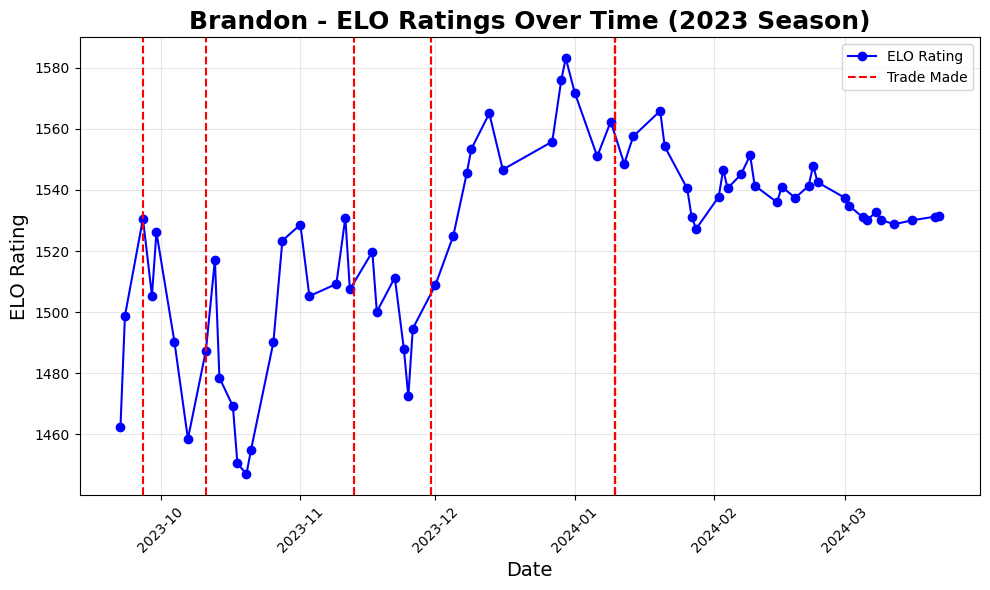

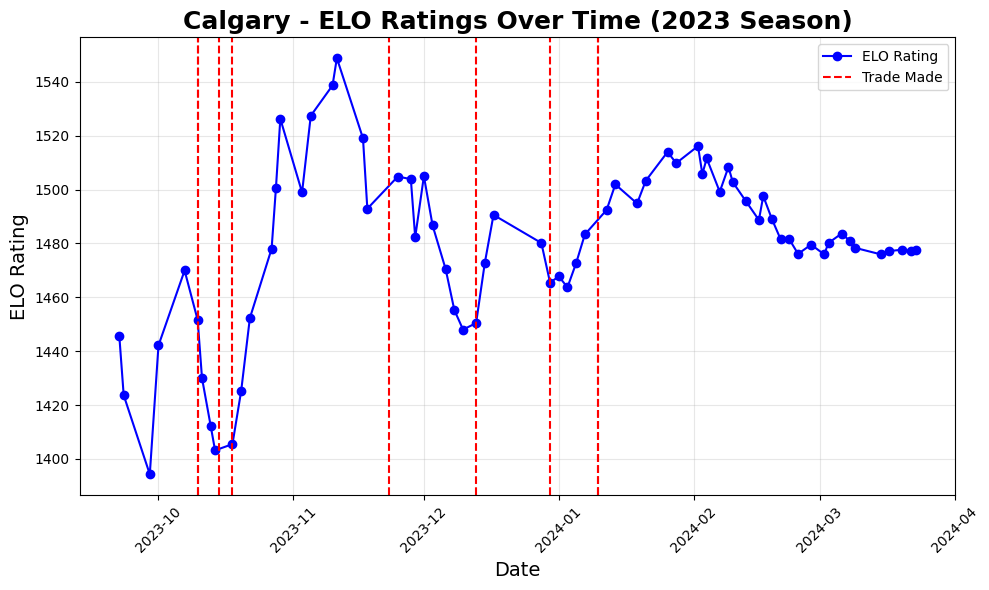

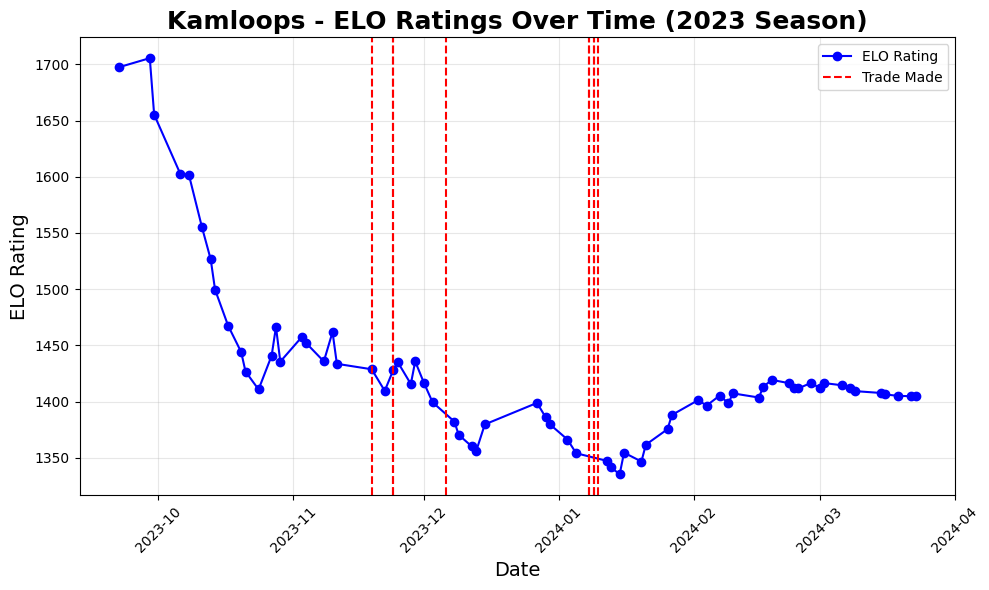

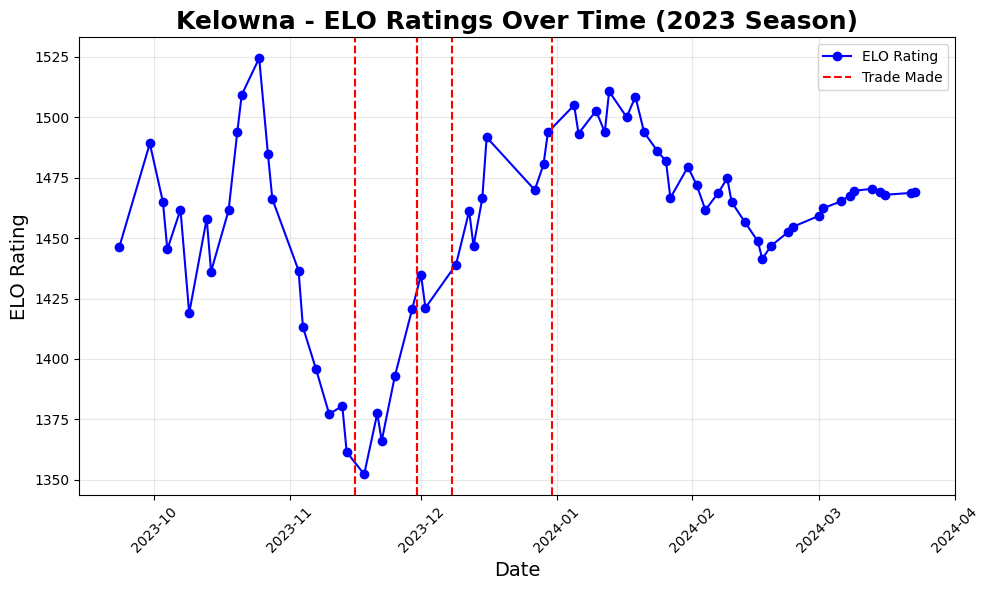

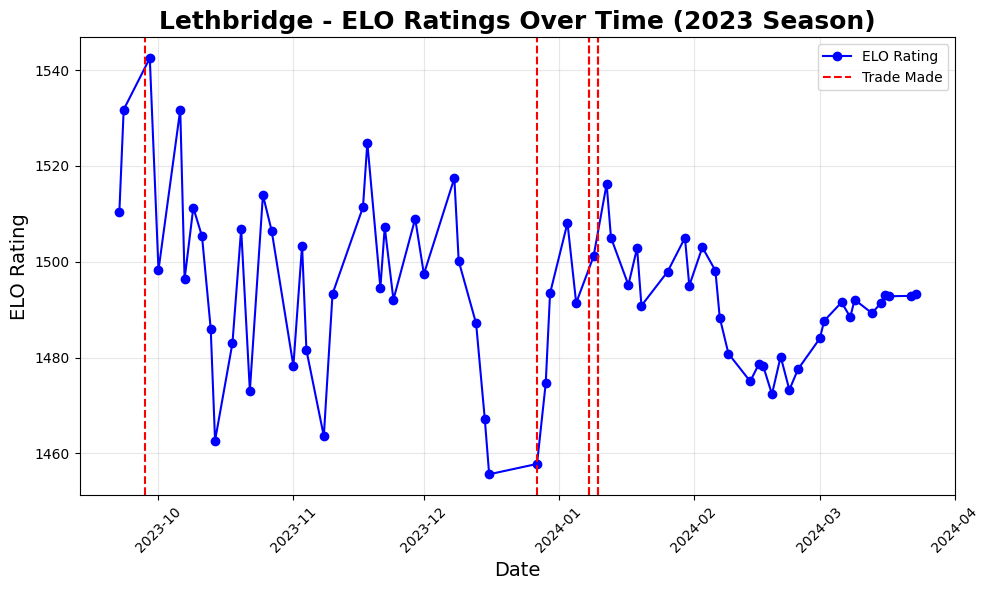

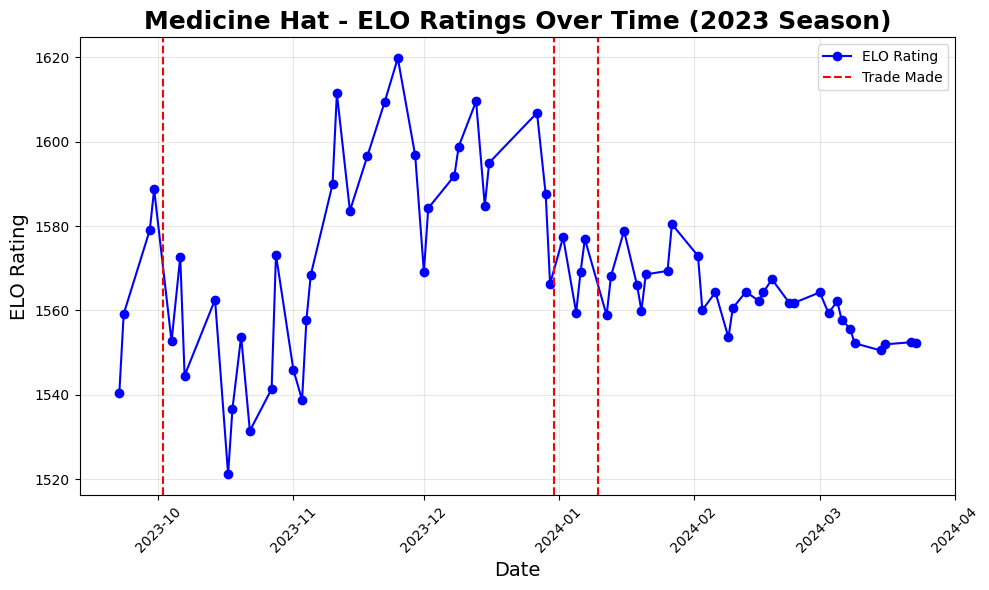

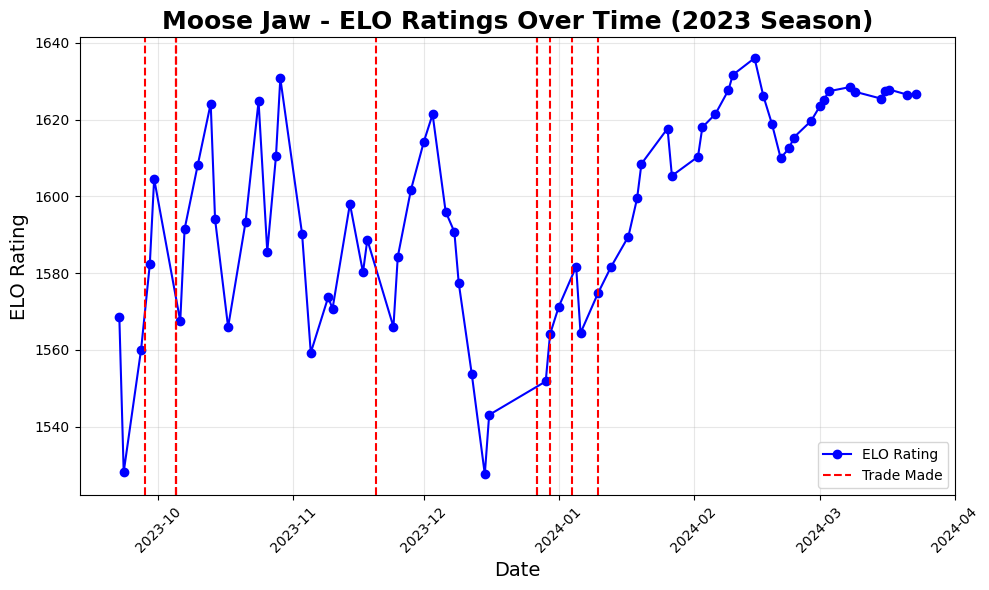

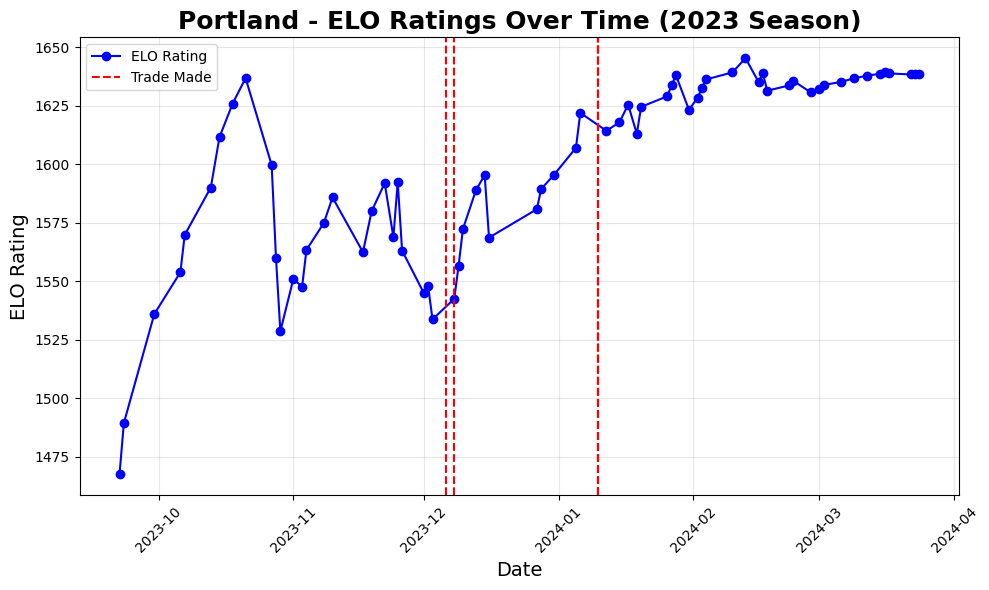

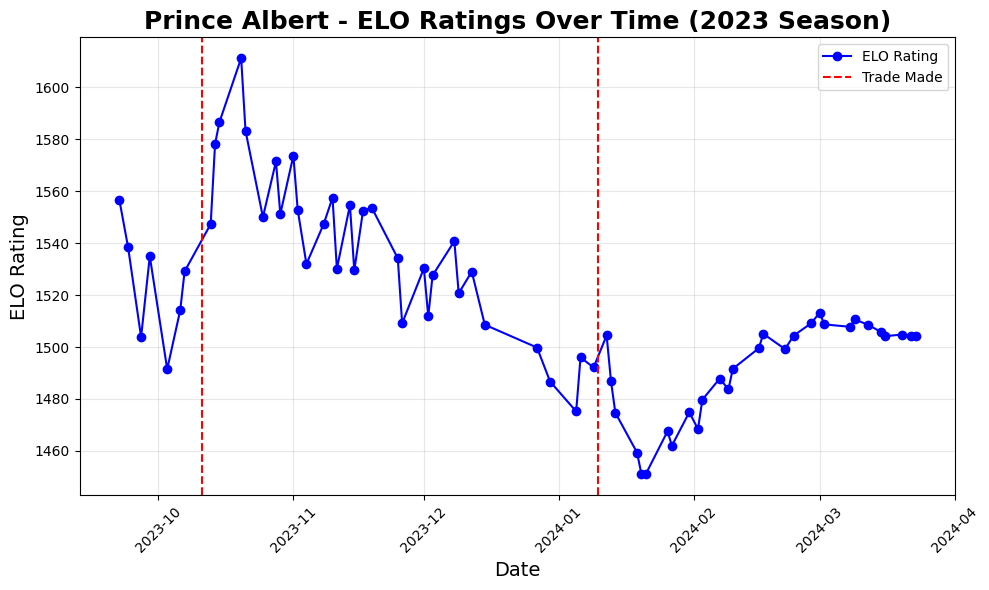

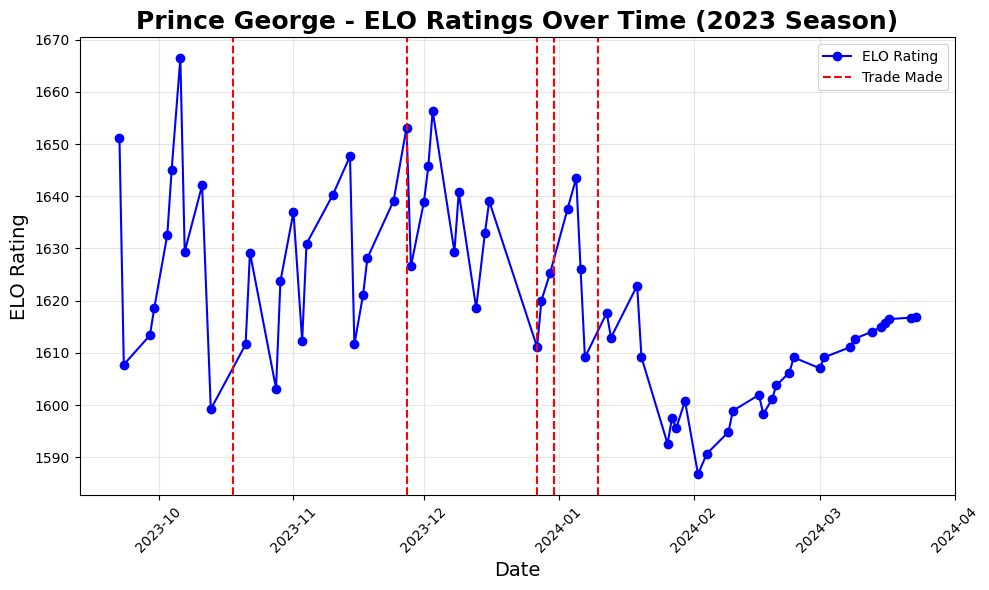

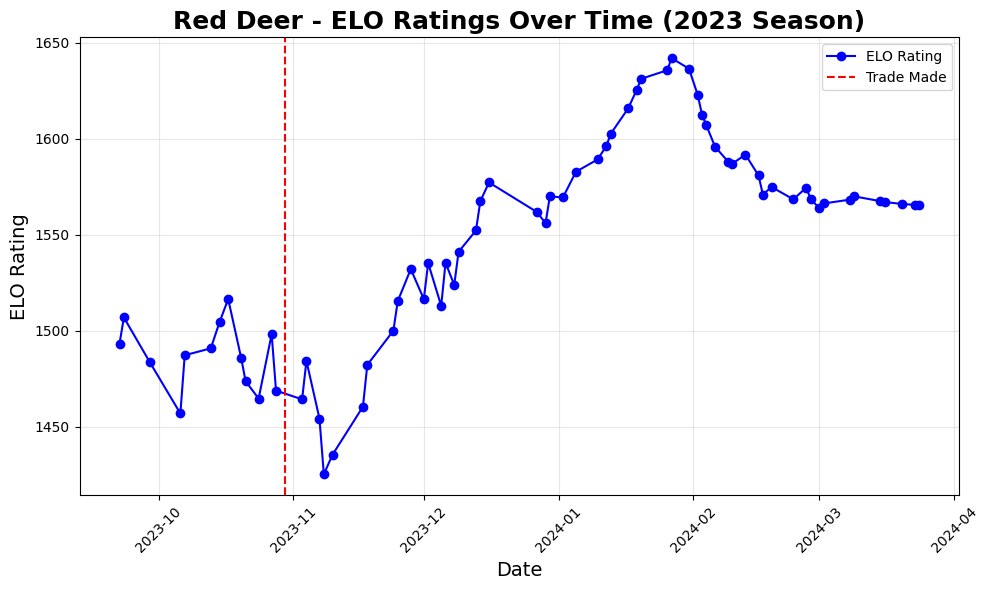

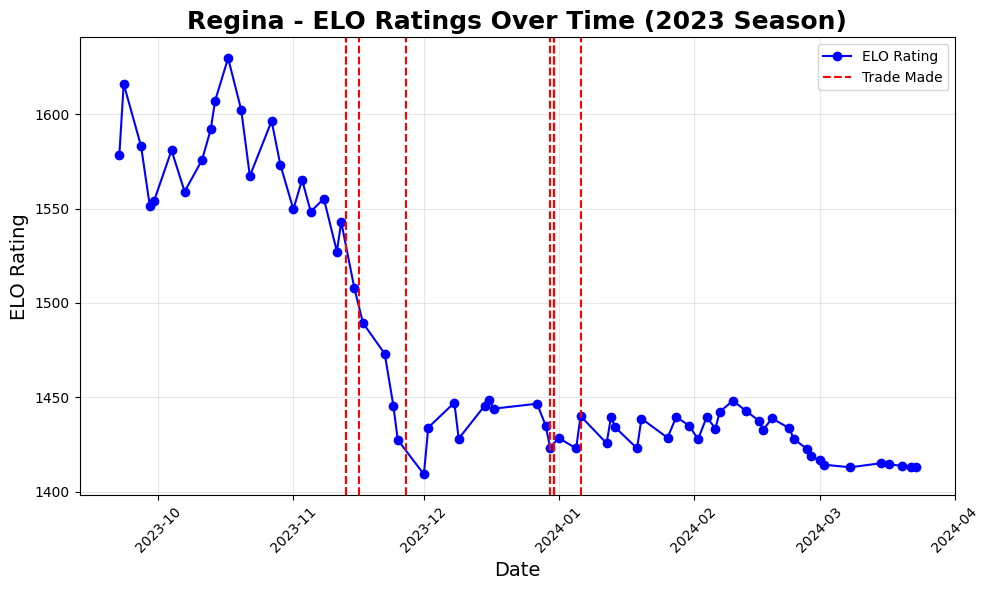

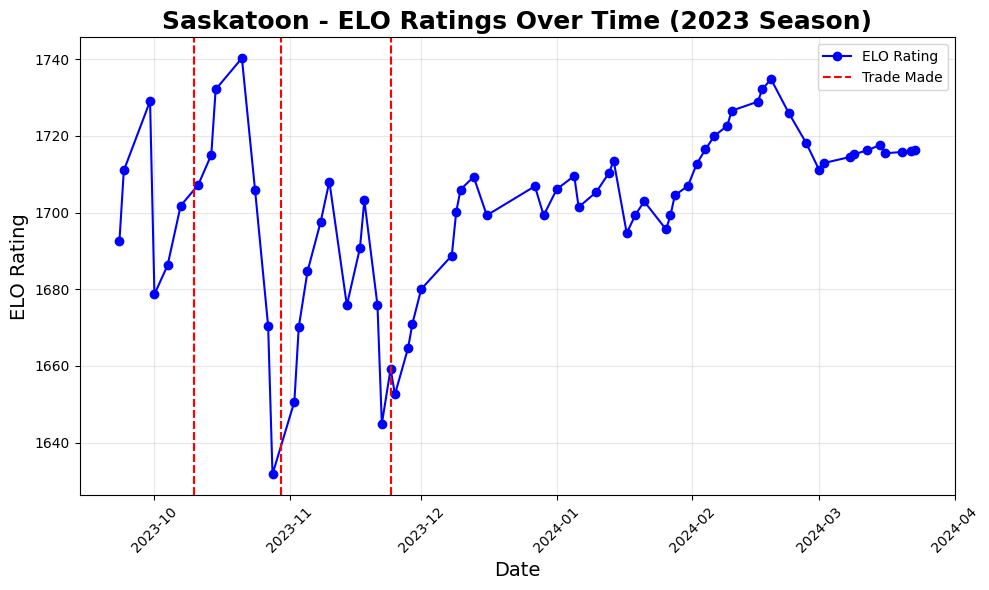

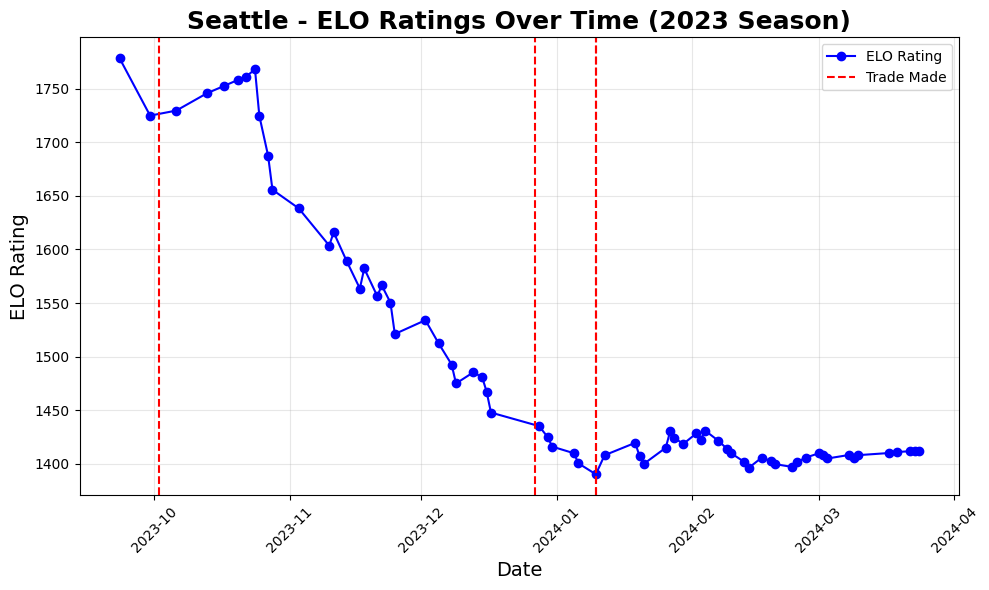

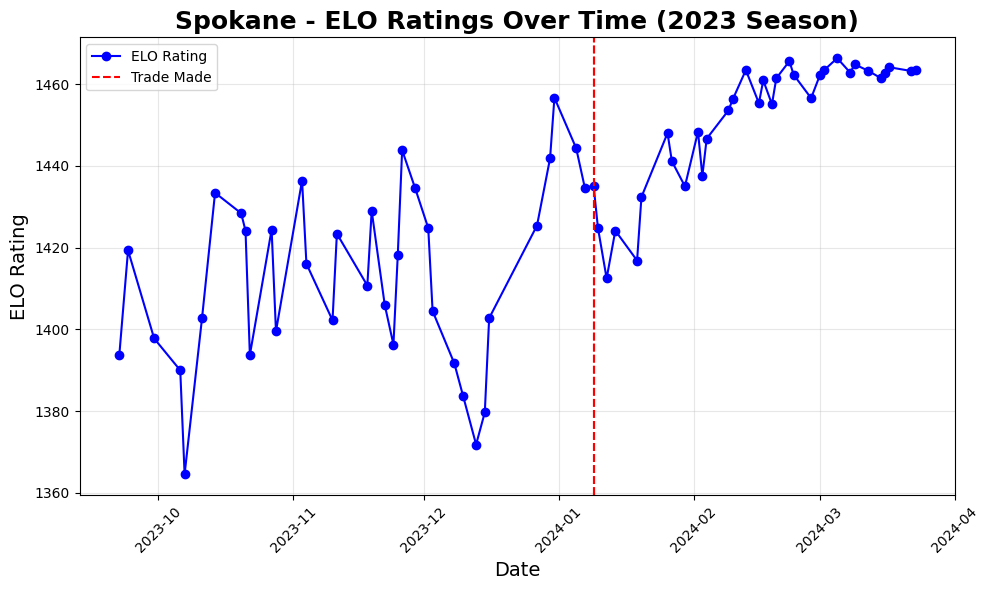

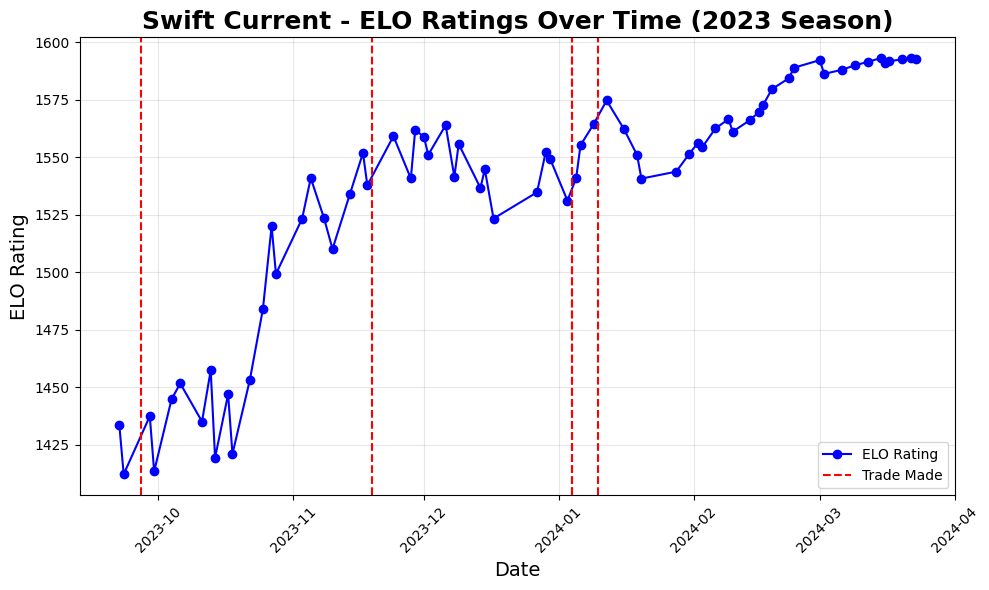

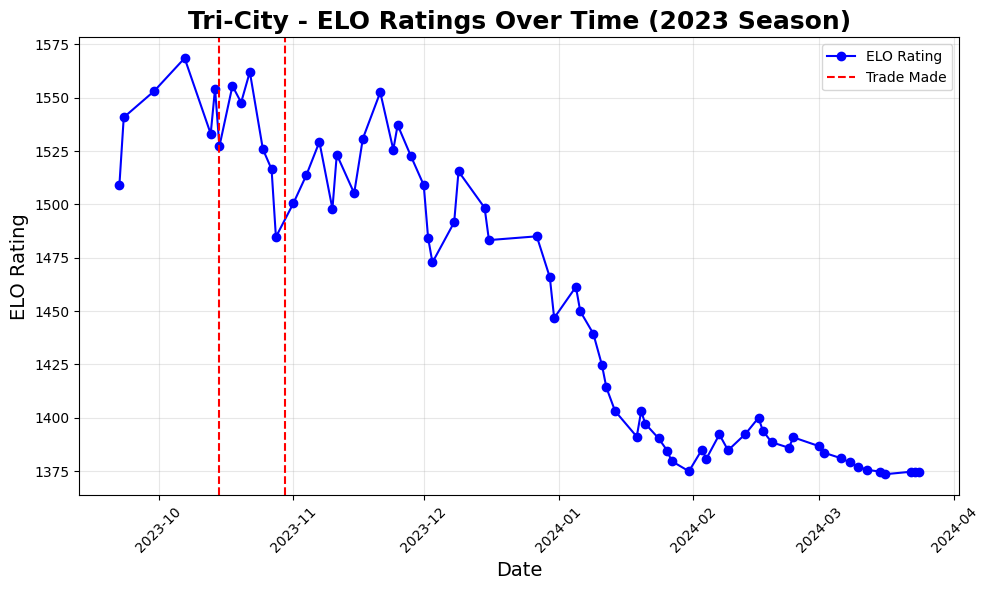

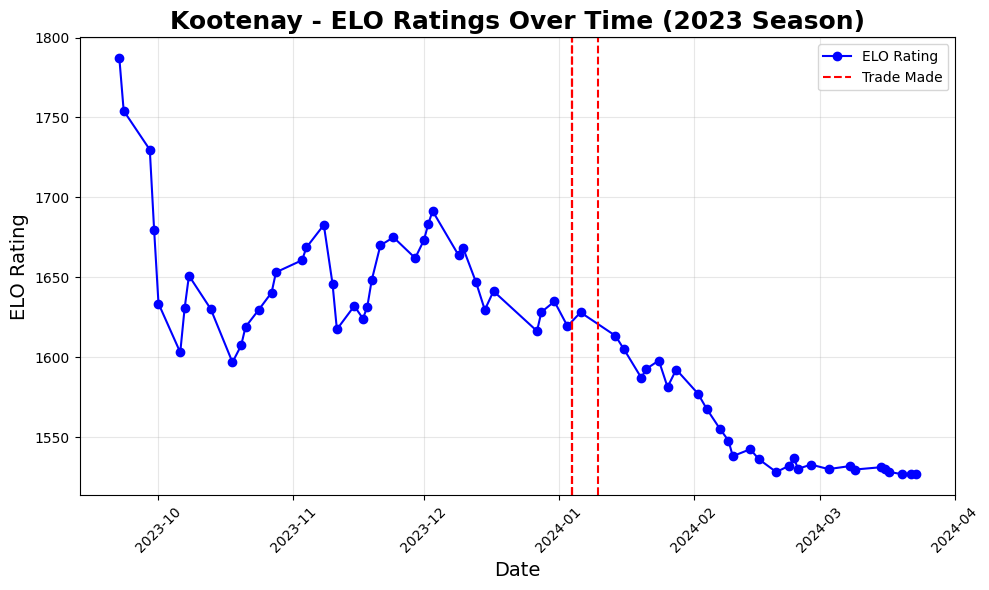

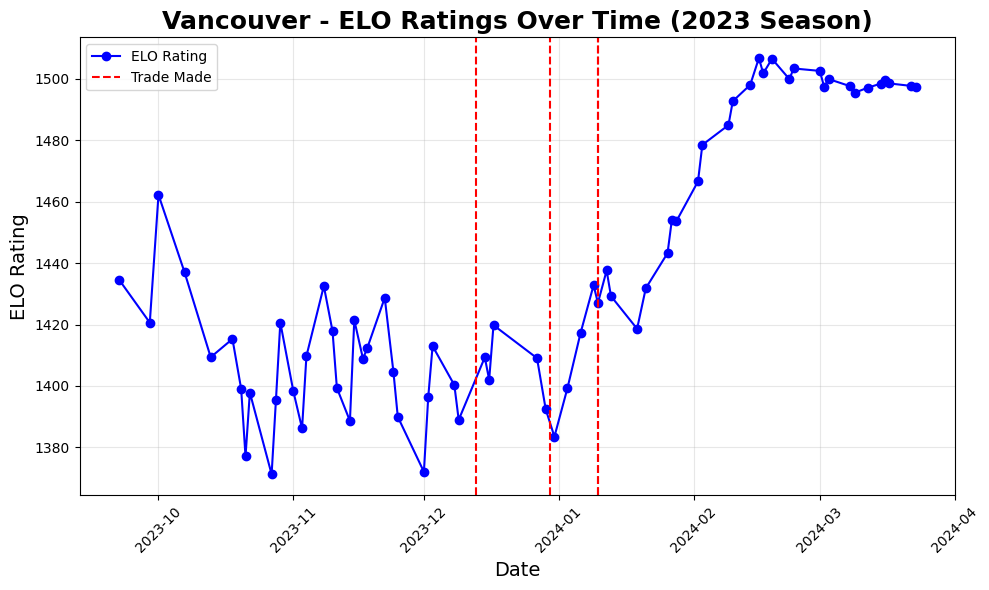

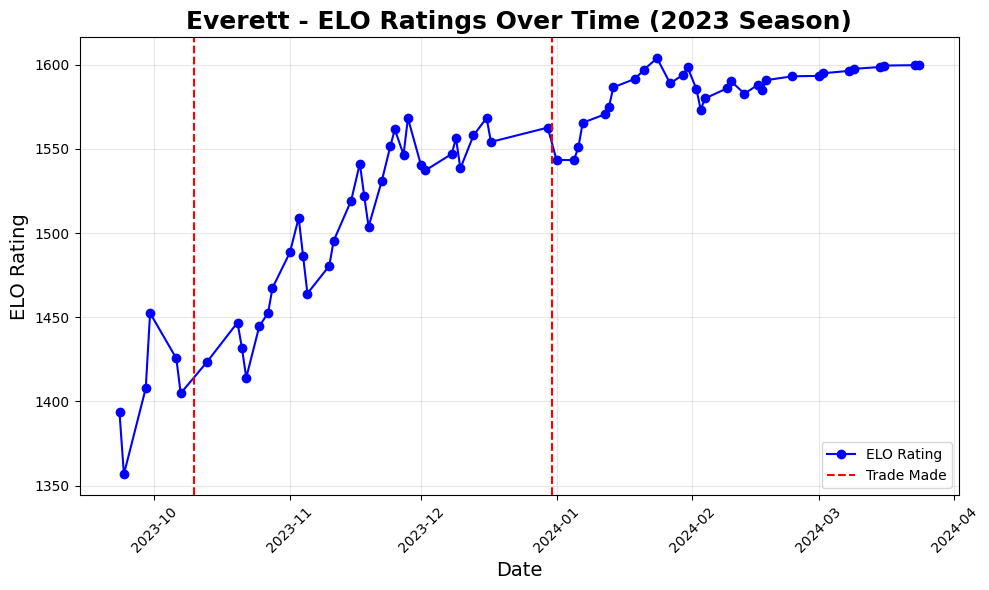

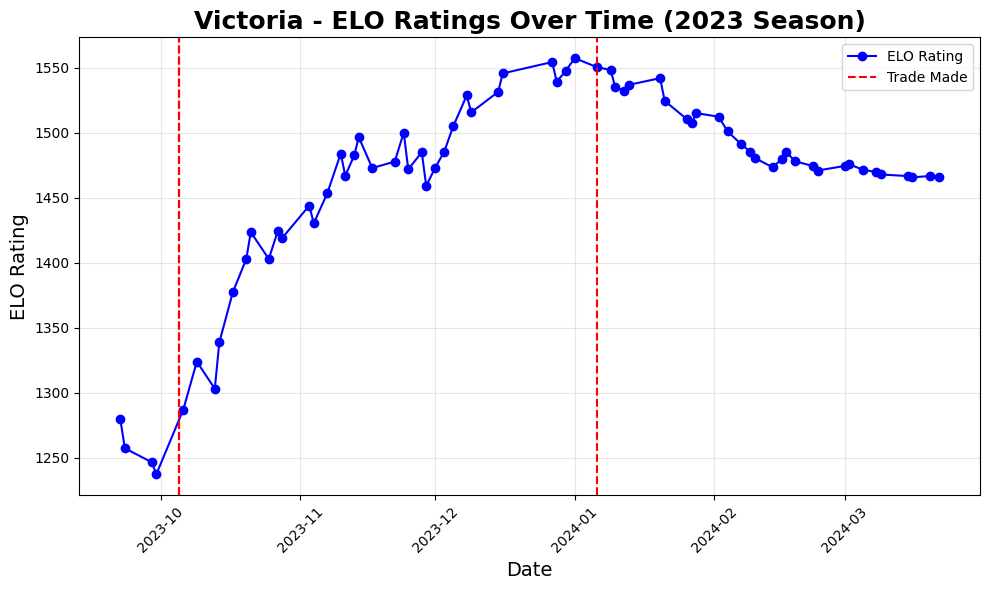

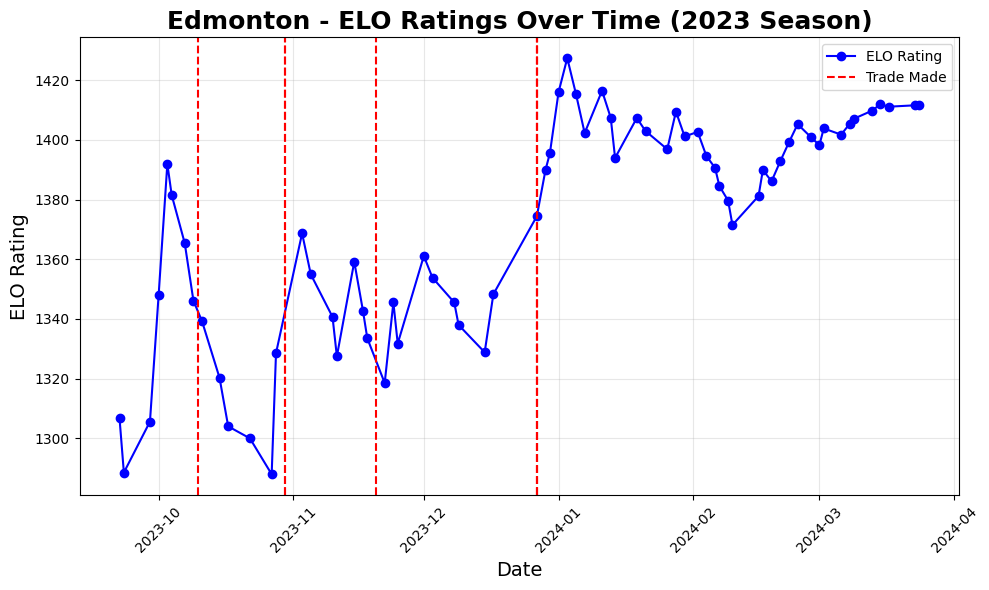

In [ ]:
# Team ID mapping dictionary
team_id_mapping = {
    '201': 'Brandon', '202': 'Calgary', '203': 'Kamloops', '204': 'Kelowna',
    '205': 'Lethbridge', '206': 'Medicine Hat', '207': 'Moose Jaw', '208': 'Portland',
    '209': 'Prince Albert', '210': 'Prince George', '211': 'Red Deer', '212': 'Regina',
    '213': 'Saskatoon', '214': 'Seattle', '215': 'Spokane', '216': 'Swift Current',
    '217': 'Tri-City', '222': 'Wenatchee', '223': 'Vancouver', '226': 'Everett',
    '227': 'Victoria', '228': 'Edmonton'
}

# Filter trade data for the 2023 season (Sep 2023 - Apr 2024)
trade_stats_df['trade_date'] = pd.to_datetime(trade_stats_df['trade_date'])
trade_stats_2023 = trade_stats_df[
    (trade_stats_df['trade_date'] >= '2023-09-01') &
    (trade_stats_df['trade_date'] <= '2024-04-30')
]

elo_datasets['date'] = pd.to_datetime(elo_datasets['date'])
elo_2023 = elo_datasets[
    (elo_datasets['date'] >= '2023-09-01') &
    (elo_datasets['date'] <= '2024-04-30')
]

teams = elo_2023['team_id'].unique()

# Plot ELO ratings for each team with trade lines
for team in teams:
    team_elo = elo_2023[elo_2023['team_id'] == team].sort_values(by='date')
    team_trades = trade_stats_2023[trade_stats_2023['team_id'] == team]

    # Skip teams without trades
    if team_trades.empty:
        continue

    if str(team) == '222':
        team_name = 'Kootenay'
    else:
        team_name = team_id_mapping.get(str(team), f"Team {team}")

    plt.figure(figsize=(10, 6))
    plt.plot(team_elo['date'], team_elo['elo'], marker='o', linestyle='-', label='ELO Rating', color='blue')

    # Add vertical red lines for each trade
    for _, trade in team_trades.iterrows():
        plt.axvline(x=trade['trade_date'], color='red', linestyle='--', linewidth=1.5, label='Trade Made' if _ == team_trades.index[0] else "")

    plt.title(f'{team_name} - ELO Ratings Over Time (2023 Season)', fontsize=18, fontweight='bold')
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('ELO Rating', fontsize=14)
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Section 8: Final Riskiest Trade Model

Remaing to-do: look at combined value of net players in trade (sum of rating of players in versus sum of rating of players out).

Use difference as predictor for increase in team ELO.

Train on 2018-2022.
Validate 2023.
Test 2024.

We were having significant trouble integrating and using our several datasets for this part. After HOURS of trial and error, including using GPT to attempt to debug, we instead decided to take another approach.

We downloaded the completed and working datafiles as CSVs, and had GPT run the code and output a resulting CSV. This approach worked, and is shown below...

In [ ]:
# Specify the path to the CSV file
csv_path = 'trade_net_values.csv'
trade_season_values_df = pd.read_csv(csv_path)

# Display the first few rows to verify
print(trade_season_values_df)

In [ ]:
# Convert date columns to datetime for proper matching
trade_season_values_df['Trade_Date'] = pd.to_datetime(trade_season_values_df['Trade_Date'])
elo_datasets['date'] = pd.to_datetime(elo_datasets['date'])

def find_closest_elo(team_id, trade_date, elo_df):
    team_elo = elo_df[elo_df['team_id'] == team_id]
    if team_elo.empty:
        return None
    closest_row = team_elo.iloc[(team_elo['date'] - trade_date).abs().argsort().iloc[0]]
    return closest_row['elo']

# Function to calculate the average Elo for the first 5 games after the trade date
def calculate_after_elo(team_id, trade_date, elo_df):
    team_elo = elo_df[(elo_df['team_id'] == team_id) & (elo_df['date'] > trade_date)]
    if team_elo.empty or len(team_elo) < 5:
        return None
    return team_elo.head(5)['elo'].mean()

trade_season_values_df['Team_A_Elo'] = trade_season_values_df.apply(
    lambda row: find_closest_elo(row['Team_A'], row['Trade_Date'], elo_datasets), axis=1
)

trade_season_values_df['Team_B_Elo'] = trade_season_values_df.apply(
    lambda row: find_closest_elo(row['Team_B'], row['Trade_Date'], elo_datasets), axis=1
)

# Calculate after Elo values (average of first 5 games following trade)
trade_season_values_df['Team_A_After_Elo'] = trade_season_values_df.apply(
    lambda row: calculate_after_elo(row['Team_A'], row['Trade_Date'], elo_datasets), axis=1
)

trade_season_values_df['Team_B_After_Elo'] = trade_season_values_df.apply(
    lambda row: calculate_after_elo(row['Team_B'], row['Trade_Date'], elo_datasets), axis=1
)

# Calculate Elo changes
trade_season_values_df['Team_A_Elo_Change'] = (
    trade_season_values_df['Team_A_After_Elo'] - trade_season_values_df['Team_A_Elo']
)

trade_season_values_df['Team_B_Elo_Change'] = (
    trade_season_values_df['Team_B_After_Elo'] - trade_season_values_df['Team_B_Elo']
)

In [ ]:
print(trade_season_values_df)

In [ ]:
# Our linear regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def prepare_data(data):
    team_a = pd.DataFrame({
        'Net_Player_Value': data['Team_A_Net_Value'],
        'Elo_Change': data['Team_A_Elo_Change']
    })
    team_b = pd.DataFrame({
        'Net_Player_Value': data['Team_B_Net_Value'],
        'Elo_Change': data['Team_B_Elo_Change']
    })
    combined = pd.concat([team_a, team_b], axis=0).dropna()
    return combined[['Net_Player_Value']], combined['Elo_Change']

# Split the data into training, validation, and test datasets
train_data = trade_season_values_df[trade_season_values_df['Season'].isin([2018, 2019,2022])]
validate_data = trade_season_values_df[trade_season_values_df['Season'] == 2023]
test_data = trade_season_values_df[trade_season_values_df['Season'] == 2024]

X_train, y_train = prepare_data(train_data)
X_val, y_val = prepare_data(validate_data)
X_test, y_test = prepare_data(test_data)

# Train the Linear Regression model on the training data
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_val_pred = lr_model.predict(X_val)
y_test_pred = lr_model.predict(X_test)

# Evaluate the model
r2_val = r2_score(y_val, y_val_pred)
r2_test = r2_score(y_test, y_test_pred)

# Output performance
print("Linear Regression R-squared Score on Validation Set (2023):", r2_val)
print("Linear Regression R-squared Score on Test Set (2024):", r2_test)

validation_results = pd.DataFrame({
    'Net_Player_Value': X_val['Net_Player_Value'],
    'Actual_Elo_Change': y_val,
    'Predicted_Elo_Change': y_val_pred
})

test_results = pd.DataFrame({
    'Net_Player_Value': X_test['Net_Player_Value'],
    'Actual_Elo_Change': y_test,
    'Predicted_Elo_Change': y_test_pred
})

Linear Regression R-squared Score on Validation Set (2023): -0.022407611671736438
Linear Regression R-squared Score on Test Set (2024): -0.04364767291708982


Random Forest MAPE on Validation Set (2023): 8.58%
Random Forest MAPE on Test Set (2024): 17.22%


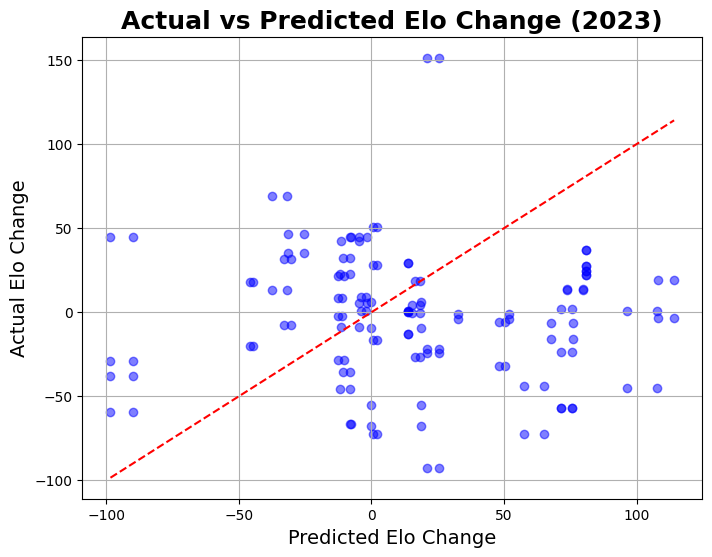

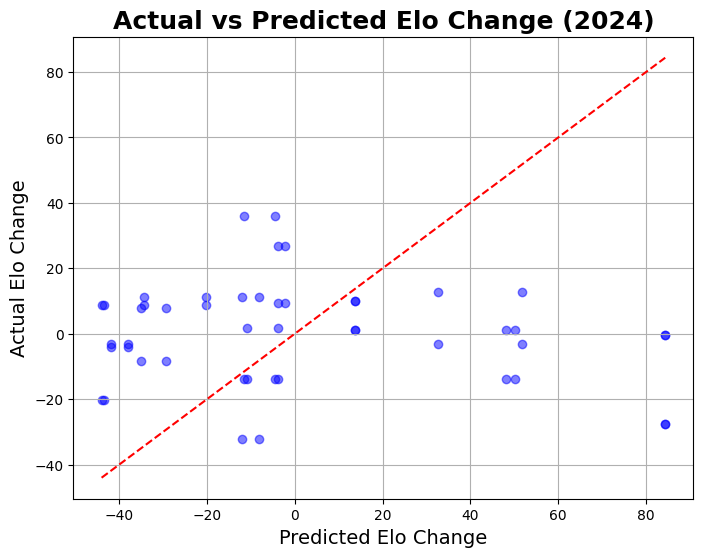

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

def prepare_data(data):
    team_a = pd.DataFrame({
        'Net_Player_Value': data['Team_A_Net_Value'],
        'Elo_Change': data['Team_A_Elo_Change']
    })
    team_b = pd.DataFrame({
        'Net_Player_Value': data['Team_B_Net_Value'],
        'Elo_Change': data['Team_B_Elo_Change']
    })
    combined = pd.concat([team_a, team_b], axis=0).dropna()
    return combined[['Net_Player_Value']], combined['Elo_Change']

train_data = trade_season_values_df[trade_season_values_df['Season'].isin([2018, 2019, 2022])]
validate_data = trade_season_values_df[trade_season_values_df['Season'] == 2023]
test_data = trade_season_values_df[trade_season_values_df['Season'] == 2024]

X_train, y_train = prepare_data(train_data)
X_val, y_val = prepare_data(validate_data)
X_test, y_test = prepare_data(test_data)

# Train a Random Forest Regressor on the training data
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on validation and test sets
y_val_pred = rf_model.predict(X_val)
y_test_pred = rf_model.predict(X_test)

# Evaluate the model using MAPE
mape_val = mean_absolute_percentage_error(y_val, y_val_pred)
mape_test = mean_absolute_percentage_error(y_test, y_test_pred)

# Output performance
print(f"Random Forest MAPE on Validation Set (2023): {mape_val:.2f}%")
print(f"Random Forest MAPE on Test Set (2024): {mape_test:.2f}%")

validation_results = pd.DataFrame({
    'Net_Player_Value': X_val['Net_Player_Value'],
    'Actual_Elo_Change': y_val,
    'Predicted_Elo_Change': y_val_pred
})
validation_results.to_csv('validation_results_rf_mape_2023.csv', index=False)

test_results = pd.DataFrame({
    'Net_Player_Value': X_test['Net_Player_Value'],
    'Actual_Elo_Change': y_test,
    'Predicted_Elo_Change': y_test_pred
})
test_results.to_csv('test_results_rf_mape_2024.csv', index=False)

def plot_actual_vs_predicted(actual, predicted, year):
    plt.figure(figsize=(8, 6))
    plt.scatter(predicted, actual, color='blue', alpha=0.5)
    plt.plot([min(predicted), max(predicted)], [min(predicted), max(predicted)],
             color='red', linestyle='--')
    plt.title(f"Actual vs Predicted Elo Change ({year})", fontsize=18, fontweight='bold')
    plt.xlabel("Predicted Elo Change", fontsize = 14)
    plt.ylabel("Actual Elo Change", fontsize = 14)
    plt.grid(True)
    plt.show()

# Plot for 2023 Validation Data
plot_actual_vs_predicted(y_val, y_val_pred, year=2023)

# Plot for 2024 Test Data
plot_actual_vs_predicted(y_test, y_test_pred, year=2024)